# Fanfics dataset analysis using Apache Spark

## Overview
- This notebook sets up and verifies a Spark environment on the SDSC Expanse cluster, then loads and validates a large-scale fanfiction dataset.

## Objectives
- Configure SparkSession from the allocated cluster resources
- Load the dataset stored on the Lustre filesystem
- Verify distributed processing
- Prepare for large-scale data analysis

## Dataset
- Source: https://huggingface.co/datasets/marianna13/fanfics

## Spark configuration

The SparkSession is configured for the resources allocated in the Expanse Jupyter environment, with two adjustments specific to this corpus.

### Allocated resources
- Total cores: 16
- Total memory: 128 GB

### Configuration formula (per `SPARK_HPC_BEST_PRACTICES.md`)
- Driver memory: 16 GB (see "Local-mode override" below)
- Executor instances: Total Cores - 1 = 15
- Executor memory: (Total Memory - Driver Memory) / Executor Instances = (128 - 16) / 15 ≈ 7.5 GB, kept at 8 GB for documentation; not active in local mode

### Local-mode override
Expanse JupyterLab launches Spark in `local[*]` mode (no YARN provisioning), so the driver JVM is the executor and all task memory pressure falls on the driver. We raise driver memory to 16 GB to give the 16 concurrent tasks enough headroom. `executor.memory` and `executor.instances` stay in the builder per the documented formula but are inactive in local mode.

### Vectorized Parquet reader disabled
The corpus contains `TEXT` records up to ~93 MB. Spark's default vectorized Parquet reader allocates contiguous buffers proportional to its batch size (4,096 rows) and column size, which OOMs the JVM when batches contain large TEXT values. Disabling vectorized reading (`spark.sql.parquet.enableVectorizedReader=false`) switches to row-by-row reads with bounded per-row memory at a small read-throughput cost, acceptable for exploratory analysis.

In [1]:
import requests
import pandas as pd

In [2]:
import os
from pyspark.sql import SparkSession

# Redirect Spark shuffle/spill scratch from /tmp (small, on compute node) to
# Lustre (TB-scale, per-user project space). This is necessary because the
# corpus has multi-MB TEXT rows; any shuffle on TEXT (e.g., dropDuplicates)
# spills enough data to exhaust /tmp on the compute node.
user = os.environ.get('USER', 'unknown')
spark_local_dir = f"/expanse/lustre/projects/uci157/{user}/spark-scratch"
os.makedirs(spark_local_dir, exist_ok=True)

spark = SparkSession.builder \
    .config("spark.driver.memory", "16g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.executor.instances", 15) \
    .config("spark.sql.parquet.enableVectorizedReader", "false") \
    .config("spark.local.dir", spark_local_dir) \
    .getOrCreate()

# Display Spark session to confirm initialization
spark

In [3]:
conf = spark.sparkContext.getConf().getAll()

for key, value in conf:
    print(f"{key}: {value}")

spark.driver.port: 44077
spark.executor.instances: 15
spark.app.submitTime: 1780075948258
spark.driver.host: exp-2-05.expanse.sdsc.edu
spark.executor.id: driver
spark.local.dir: /expanse/lustre/projects/uci157/mhayeri/spark-scratch
spark.driver.memory: 16g
spark.app.startTime: 1780075948389
spark.app.name: pyspark-shell
spark.app.id: local-1780075949106
spark.driver.extraJavaOptions: -Djava.net.preferIPv6Addresses=false -XX:+IgnoreUnrecognizedVMOptions --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.

In [4]:
print("Default Parallelism:", spark.sparkContext.defaultParallelism)

Default Parallelism: 16


In [5]:
import os
import glob

# ----------------------------------------
# Load Dataset from Lustre Filesystem
# ----------------------------------------
# Each member has his own 186 GB corpus copy at <repo>/shared/fanfics/.
# Resolve the path portably so either member's run finds his own copy.

candidates = [
    os.path.join(os.path.dirname(os.getcwd()), "shared", "fanfics"),  # repo-relative when cwd=notebook/
    os.path.join(os.getcwd(), "shared", "fanfics"),                    # repo-relative when cwd=repo root
    "/expanse/lustre/projects/uci157/dpham5/fanfic-spark-analysis/shared/fanfics",  # Derek absolute
    "/expanse/lustre/projects/uci157/mhayeri/fanfics-analysis/shared/fanfics",       # Mustafa absolute
]
data_path = next((p for p in candidates if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError(f"None of the candidate corpus paths exist: {candidates}")
print(f"Using data path: {data_path}")

# ----------------------------------------
# Schema heterogeneity across Parquet shards
# ----------------------------------------
# The marianna13/fanfics corpus was produced in heterogeneous batches:
#   - `language` is encoded as string in most shards but as INT32 in some
#   - `__null_dask_index__` is present in some shards but not others
# Spark's default read picks one global schema and fails on mismatches:
#
#   Py4JJavaError: Parquet column cannot be converted in file
#       part-03500-...snappy.parquet. Column: [language],
#       Expected: string, Found: INT32.
#
# Workaround: read each shard's footer, split the file list by `language`
# physical type, load the two subsets, cast the INT32 subset to string, and
# union with allowMissingColumns=True so column-set differences become NULL.
# This preserves all rows; the heterogeneity is itself a finding documented
# in §3 frequency tables and addressed in the §5 preprocessing plan.

from pyspark.sql.functions import col

all_files = sorted(glob.glob(f"{data_path}/*.parquet"))
print(f"Total shards on disk: {len(all_files)}")

# Use pyarrow for fast metadata reads if available; fall back to Spark otherwise.
try:
    import pyarrow.parquet as pq
    def _lang_type(f):
        return str(pq.read_metadata(f).schema.to_arrow_schema().field('language').type)
except ImportError:
    def _lang_type(f):
        return dict(spark.read.parquet(f).dtypes).get('language', 'MISSING')

str_files = []
int_files = []
for i, f in enumerate(all_files):
    t = _lang_type(f)
    if t == 'string':
        str_files.append(f)
    else:
        int_files.append(f)
    if (i + 1) % 200 == 0:
        print(f"  Scanned {i+1}/{len(all_files)} schemas...")

print(f"String-language shards: {len(str_files)}")
print(f"Int-language shards:    {len(int_files)}")

parts = []
if str_files:
    parts.append(spark.read.parquet(*str_files))
if int_files:
    parts.append(
        spark.read.parquet(*int_files).withColumn("language", col("language").cast("string"))
    )

df = parts[0]
for p in parts[1:]:
    df = df.unionByName(p, allowMissingColumns=True)

print("Dataset successfully loaded with normalized language schema.")

Using data path: /expanse/lustre/projects/uci157/mhayeri/fanfics-analysis/shared/fanfics
Total shards on disk: 2018
  Scanned 200/2018 schemas...
  Scanned 400/2018 schemas...
  Scanned 600/2018 schemas...
  Scanned 800/2018 schemas...
  Scanned 1000/2018 schemas...
  Scanned 1200/2018 schemas...
  Scanned 1400/2018 schemas...
  Scanned 1600/2018 schemas...
  Scanned 1800/2018 schemas...
  Scanned 2000/2018 schemas...
String-language shards: 2016
Int-language shards:    2
Dataset successfully loaded with normalized language schema.


In [6]:
# ----------------------------------------
# Trigger Spark Job to Validate Data Loading
# ----------------------------------------

row_count = df.count()
print(f"Total number of observations: {row_count}")

Total number of observations: 5252058


In [7]:
# ----------------------------------------
# Inspect Dataset Schema
# ----------------------------------------

df.printSchema()

root
 |-- __null_dask_index__: long (nullable = true)
 |-- TEXT: string (nullable = true)
 |-- CATEGORY: string (nullable = true)
 |-- SOURCE: string (nullable = true)
 |-- language: string (nullable = true)
 |-- text_len: long (nullable = true)
 |-- perplexity_score: double (nullable = true)



In [8]:
# ----------------------------------------
# Check Number of Partitions
# ----------------------------------------

num_partitions = df.rdd.getNumPartitions()

print("Number of partitions:", num_partitions)

Number of partitions: 1945


## Section 3: Data exploration

All exploration uses Spark DataFrames per the assignment requirement. The §4 plots use sampled or aggregated results converted to Pandas after the Spark stages.

### 3a. Total observation count

`df.count()` is shown above (5,252,058 rows).

### 3b. Column descriptions and distributions

Numeric columns (`text_len`, `perplexity_score`) get `describe()`. Categorical columns (`CATEGORY`, `SOURCE`, `language`) get frequency tables and distinct counts. The `__null_dask_index__` column is a Dask leftover that we drop in preprocessing.

In [9]:
df.describe(["text_len", "perplexity_score"]).show()

+-------+------------------+------------------+
|summary|          text_len|  perplexity_score|
+-------+------------------+------------------+
|  count|           5252058|           5252058|
|   mean| 59265.66334377876|12093.941925317644|
| stddev|147270.26689221288|2866.4860636911285|
|    min|              5001|              56.8|
|    max|          93626685|           69992.0|
+-------+------------------+------------------+



In [10]:
from pyspark.sql import functions as F

df.groupBy('language').count().orderBy(F.desc('count')).show(30, truncate=False)
print("Distinct languages:", df.select('language').distinct().count())

+--------+-------+
|language|count  |
+--------+-------+
|en      |4591384|
|es      |292400 |
|fr      |137479 |
|id      |121040 |
|pt      |58073  |
|de      |24970  |
|pl      |7454   |
|NULL    |3088   |
|da      |2990   |
|it      |2264   |
|ru      |2045   |
|hu      |2008   |
|nl      |1572   |
|sv      |1171   |
|cs      |1057   |
|fi      |972    |
|tl      |692    |
|ca      |387    |
|sk      |267    |
|ro      |117    |
|no      |97     |
|tr      |91     |
|he      |73     |
|hr      |57     |
|el      |57     |
|bg      |54     |
|ar      |31     |
|so      |22     |
|sw      |20     |
|af      |18     |
+--------+-------+
only showing top 30 rows

Distinct languages: 45


In [11]:
df.groupBy('SOURCE').count().orderBy(F.desc('count')).show(10, truncate=False)
print("Distinct SOURCE values:", df.select('SOURCE').distinct().count())

+----------+-------+
|SOURCE    |count  |
+----------+-------+
|Fanfiction|5252058|
+----------+-------+

Distinct SOURCE values: 1


In [12]:
df.groupBy('CATEGORY').count().orderBy(F.desc('count')).show(50, truncate=False)
print("Approx distinct CATEGORY values:",
      df.agg(F.approx_count_distinct('CATEGORY')).collect()[0][0])

+-------------------------------------+------+
|CATEGORY                             |count |
+-------------------------------------+------+
|                                     |242546|
|Harry Potter, Romance                |83528 |
|Harry Potter, Humor, Romance         |66201 |
|Harry Potter, Drama, Romance         |58962 |
|Harry Potter                         |47382 |
|Naruto, Romance                      |44502 |
|Naruto, Humor, Romance               |44427 |
|Naruto, Drama, Romance               |34016 |
|Harry Potter, Angst, Romance         |31134 |
|Harry Potter, Adventure, Romance     |23142 |
|Naruto, Adventure, Romance           |21268 |
|Harry Potter, Humor                  |20818 |
|Naruto                               |18820 |
|Harry Potter, Hurt-Comfort, Romance  |15748 |
|Harry Potter, Friendship, Romance    |15622 |
|Naruto, Hurt-Comfort, Romance        |15057 |
|Glee, Romance                        |14258 |
|Naruto, Angst, Romance               |13358 |
|Hetalia - Ax

In [13]:
quantiles_text_len = df.approxQuantile("text_len",
    [0.0, 0.01, 0.25, 0.5, 0.75, 0.9, 0.99, 1.0], 0.001)
quantiles_perp = df.approxQuantile("perplexity_score",
    [0.0, 0.01, 0.25, 0.5, 0.75, 0.9, 0.99, 1.0], 0.001)

print("text_len quantiles:        ", quantiles_text_len)
print("perplexity_score quantiles:", quantiles_perp)

text_len quantiles:         [5001.0, 5150.0, 9596.0, 19209.0, 51525.0, 135217.0, 588915.0, 93626685.0]
perplexity_score quantiles: [56.8, 8693.9, 10563.5, 11563.8, 12894.8, 14576.2, 21649.8, 69992.0]


### 3c. Missing and duplicate values

Nulls are counted per column with a single aggregation. Duplicates are defined by exact `TEXT` equality, the practical definition for a text corpus where the same prose may appear under multiple `CATEGORY` rows. To keep the shuffle tractable on multi-MB TEXT values, we hash each TEXT to a 32-byte md5 digest first and count distinct hashes; collisions at this scale are astronomically unlikely (~2^-128).

In [14]:
df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show(truncate=False)

+-------------------+----+--------+------+--------+--------+----------------+
|__null_dask_index__|TEXT|CATEGORY|SOURCE|language|text_len|perplexity_score|
+-------------------+----+--------+------+--------+--------+----------------+
|5119306            |0   |0       |0     |3088    |0       |0               |
+-------------------+----+--------+------+--------+--------+----------------+



In [15]:
# Duplicate detection via md5 hash of TEXT.
# A direct dropDuplicates(['TEXT']) shuffles full TEXT values (up to ~93 MB
# each) and exhausts local scratch on the compute node. Hashing TEXT to a
# 32-byte digest first keeps the shuffle tractable; md5 collisions at this
# scale are astronomically unlikely (~2^-128).
total = df.count()
unique_texts = df.select(F.md5('TEXT').alias('text_hash')).distinct().count()
print(f"Total rows:           {total:,}")
print(f"Unique TEXT rows:     {unique_texts:,}")
print(f"Duplicate TEXT rows:  {total - unique_texts:,}")

Total rows:           5,252,058
Unique TEXT rows:     4,914,503
Duplicate TEXT rows:  337,555


## Spark UI verification

The Spark UI screenshot below shows:
- Active executors
- Tasks distributed across nodes

This confirms that Spark processes the dataset in a distributed way.

In [16]:
sc = spark.sparkContext

url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

response = requests.get(url)
executors = response.json()

# Convert to DataFrame
exec_df = pd.DataFrame(executors)[
    ['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']
]

# Convert memory to GB
exec_df['maxMemory_GB'] = (exec_df['maxMemory'] / (1024**3)).round(2)

exec_df

,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,16,10119177830,0,True,9.42


## Section 4: Data plots

Plotting workflow: Spark aggregation or sampling, then `.toPandas()`, then matplotlib. Sampling uses a small fraction (~0.1%) for histograms and scatter plots; bar charts use the full aggregated counts. Each plot is followed by a written interpretation.

Notes from §3 that drive the plot choices:
- 45 distinct language tags (heavy English dominance)
- `text_len` ranges from 5,001 to ~93 million characters per record (single-record outliers up to ~93 MB)
- `perplexity_score` ranges from ~57 to ~70,000
- 278,388 distinct `CATEGORY` values; the top value is the empty string (242,546 rows), a known data-quality artifact handled in §5

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import functions as F

plt.rcParams['figure.figsize'] = (10, 5)

Matplotlib created a temporary cache directory at /scratch/mhayeri/job_49874339/matplotlib-j9fhfjsf because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


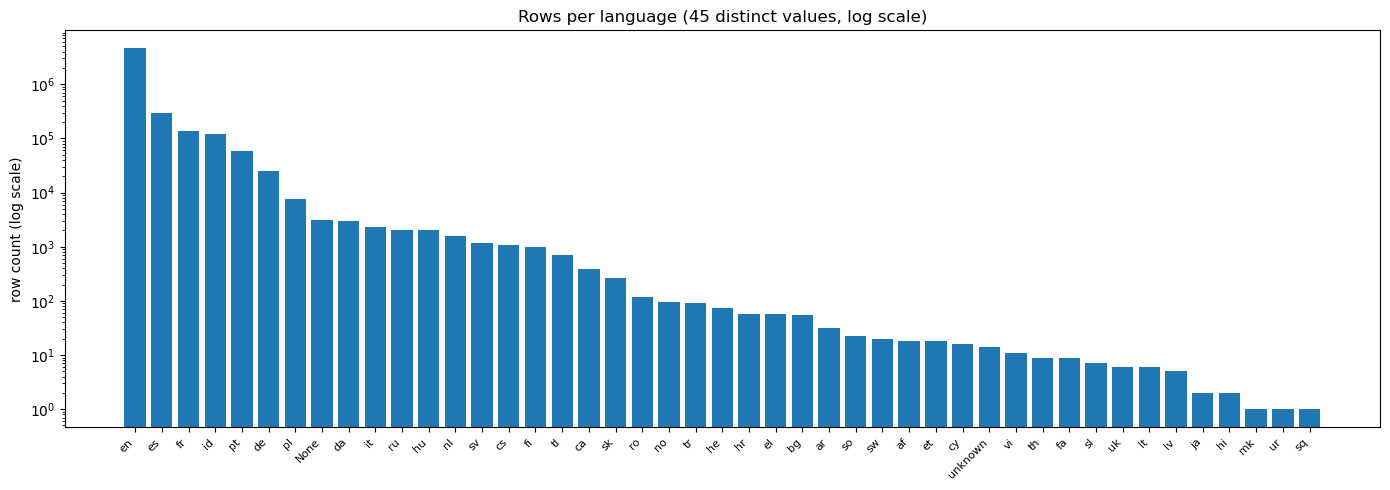

Distinct languages: 45
Top 5 languages by row count:
language   count
      en 4591384
      es  292400
      fr  137479
      id  121040
      pt   58073


In [18]:
# Plot 1: Rows per language (log-scale bar over all distinct languages)
lang_counts = (
    df.groupBy('language')
      .count()
      .orderBy(F.desc('count'))
      .toPandas()
)

plt.figure(figsize=(14, 5))
plt.bar(lang_counts['language'].astype(str), lang_counts['count'])
plt.yscale('log')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylabel('row count (log scale)')
plt.title(f'Rows per language ({len(lang_counts)} distinct values, log scale)')
plt.tight_layout()
plt.show()

print(f'Distinct languages: {len(lang_counts)}')
print(f'Top 5 languages by row count:')
print(lang_counts.head(5).to_string(index=False))

Plot 1 shows the row count per language on a log scale across all 45 distinct language tags, which makes the language imbalance clear. English has many orders of magnitude more rows than the smallest tier. This imbalance shapes the §5 preprocessing plan: any cross-lingual transfer evaluation has to account for low-resource languages, and per-language stratified sampling has to handle the long tail. The 45 distinct tags are more than the 22 the abstract assumed; §3 records the corrected count.

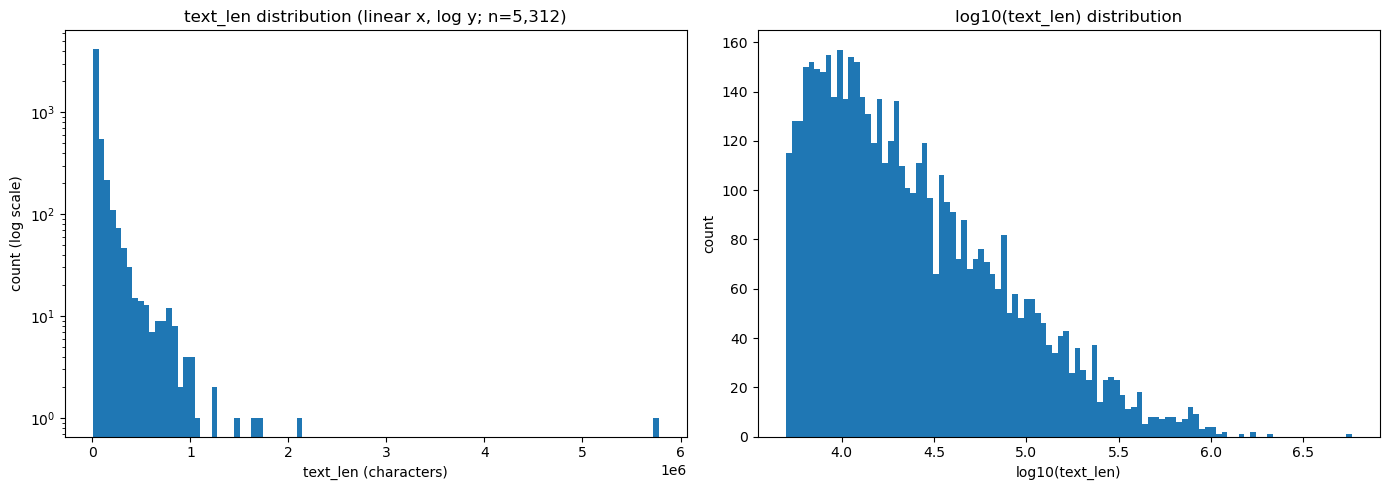

text_len sample summary:
count       5312.00
mean       58105.96
std       141646.51
min         5001.00
25%         9743.50
50%        19454.00
75%        51412.50
max      5775971.00


In [19]:
# Plot 2: text_len distribution, linear and log10 views (0.1% sample, ~5K rows)
sample_text_len = df.sample(fraction=0.001, seed=42).select('text_len').toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sample_text_len['text_len'], bins=100)
axes[0].set_yscale('log')
axes[0].set_xlabel('text_len (characters)')
axes[0].set_ylabel('count (log scale)')
axes[0].set_title(f'text_len distribution (linear x, log y; n={len(sample_text_len):,})')

axes[1].hist(np.log10(sample_text_len['text_len'].clip(lower=1)), bins=100)
axes[1].set_xlabel('log10(text_len)')
axes[1].set_ylabel('count')
axes[1].set_title('log10(text_len) distribution')

plt.tight_layout()
plt.show()

print('text_len sample summary:')
print(sample_text_len['text_len'].describe().round(2).to_string())

Plot 2 shows the `text_len` distribution. The histogram is heavily right-skewed: most records sit in the few-thousand-character range, with a long tail out to multi-million-character outliers. The linear-x view is unreadable on its own, so a log10-x version sits next to it, and that version shows an approximately log-normal body. From the §3 quantiles, the largest single-record `TEXT` reaches ~93 MB (about 93 million characters), far larger than the ~6 MB the abstract assumed. These mega-records drive the §5 preprocessing decisions: cap or filter `text_len` at the 99th percentile to prevent partition skew during downstream model training, and keep the vectorized Parquet reader disabled because of these outliers.

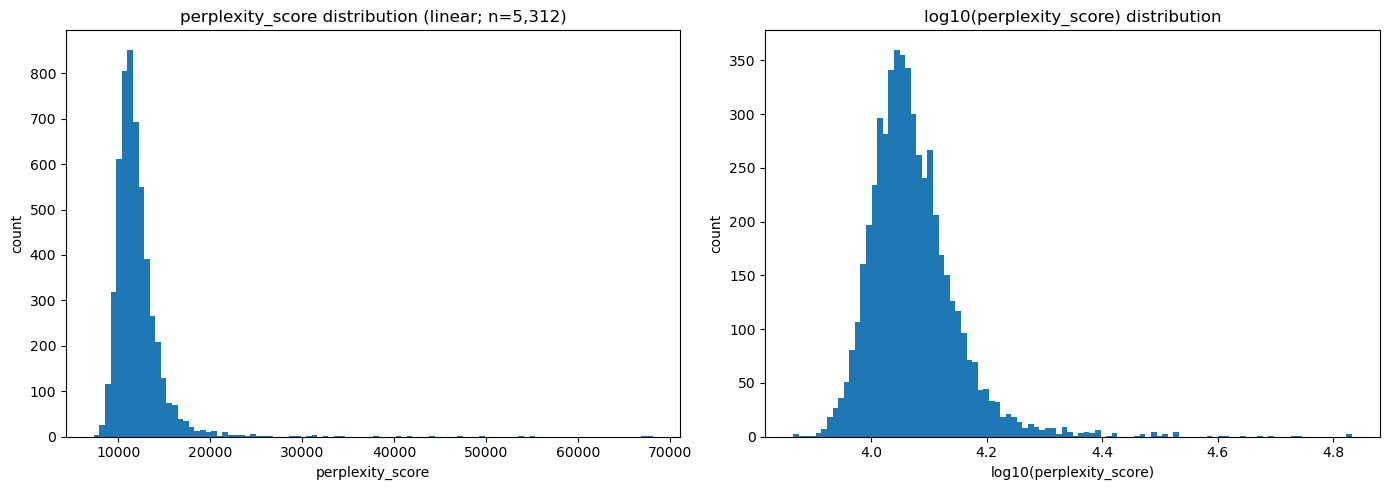

perplexity_score sample summary:
count     5312.00
mean     12046.53
std       2903.95
min       7330.90
25%      10555.92
50%      11518.85
75%      12812.15
max      68056.20


In [20]:
# Plot 3: perplexity_score distribution (0.1% sample)
sample_perp = df.sample(fraction=0.001, seed=42).select('perplexity_score').toPandas()
sample_perp = sample_perp['perplexity_score'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sample_perp, bins=100)
axes[0].set_xlabel('perplexity_score')
axes[0].set_ylabel('count')
axes[0].set_title(f'perplexity_score distribution (linear; n={len(sample_perp):,})')

axes[1].hist(np.log10(sample_perp.clip(lower=1)), bins=100)
axes[1].set_xlabel('log10(perplexity_score)')
axes[1].set_ylabel('count')
axes[1].set_title('log10(perplexity_score) distribution')

plt.tight_layout()
plt.show()

print('perplexity_score sample summary:')
print(sample_perp.describe().round(2).to_string())

Plot 3 shows the `perplexity_score` distribution. Perplexity measures how predictable each record is under a baseline language model. The linear-x view is dominated by a few extreme high-perplexity outliers (the §3 maximum was ~70,000), so a log10-x version sits next to it, and that version shows the bulk of the corpus in a much narrower predictability band. The shape of this distribution sets the §5 quality-filter threshold: extreme high-perplexity records (gibberish, broken encodings, non-natural-language artifacts) can be excluded, and extreme low-perplexity records (boilerplate, copy-paste artifacts) likely carry little useful signal.

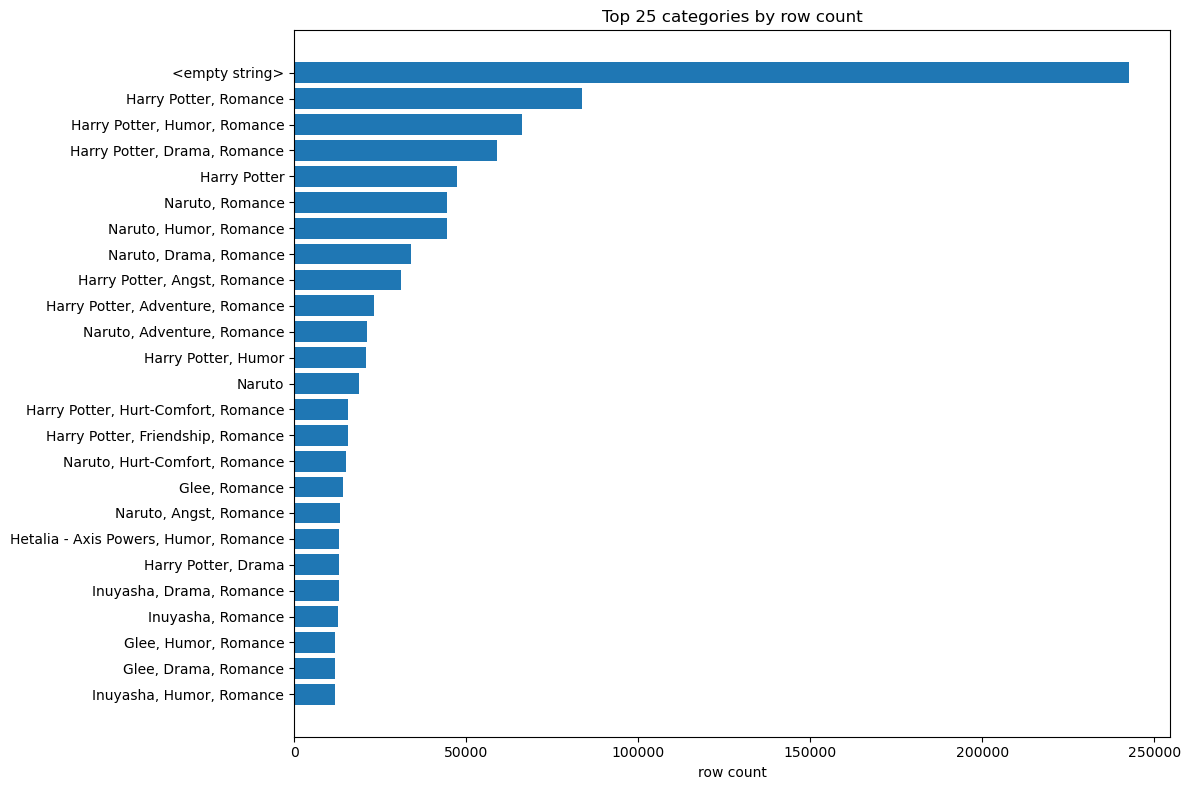

Total distinct CATEGORY values (from §3): 278,388
Top 5 categories shown:
              CATEGORY_label  count
              <empty string> 242546
       Harry Potter, Romance  83528
Harry Potter, Humor, Romance  66201
Harry Potter, Drama, Romance  58962
                Harry Potter  47382


In [21]:
# Plot 4: Top-25 categories by row count (horizontal bar)
top_cats = (
    df.groupBy('CATEGORY')
      .count()
      .orderBy(F.desc('count'))
      .limit(25)
      .toPandas()
)

# Replace the empty-string CATEGORY label with a visible placeholder for plotting
top_cats['CATEGORY_label'] = top_cats['CATEGORY'].replace('', '<empty string>')

plt.figure(figsize=(12, 8))
plt.barh(top_cats['CATEGORY_label'][::-1], top_cats['count'][::-1])
plt.xlabel('row count')
plt.title('Top 25 categories by row count')
plt.tight_layout()
plt.show()

print(f'Total distinct CATEGORY values (from §3): 278,388')
print(f'Top 5 categories shown:')
print(top_cats[['CATEGORY_label', 'count']].head(5).to_string(index=False))

Plot 4 shows the top-25 categories. The target column is heavily long-tailed: of 278,388 distinct `CATEGORY` values, the top entry is the empty string (242,546 rows), which is a data-quality artifact rather than a real category. After that, the named fandoms (Harry Potter, Naruto, and so on) outweigh the rest of the tail by one to two orders of magnitude. For Milestone 3 we (a) drop empty-`CATEGORY` rows entirely, then (b) restrict the classifier to the top-K most frequent named categories (K ≈ 50, refined from this plot) and roll the remaining tail into an "other" class. This keeps the problem tractable and class balance manageable.

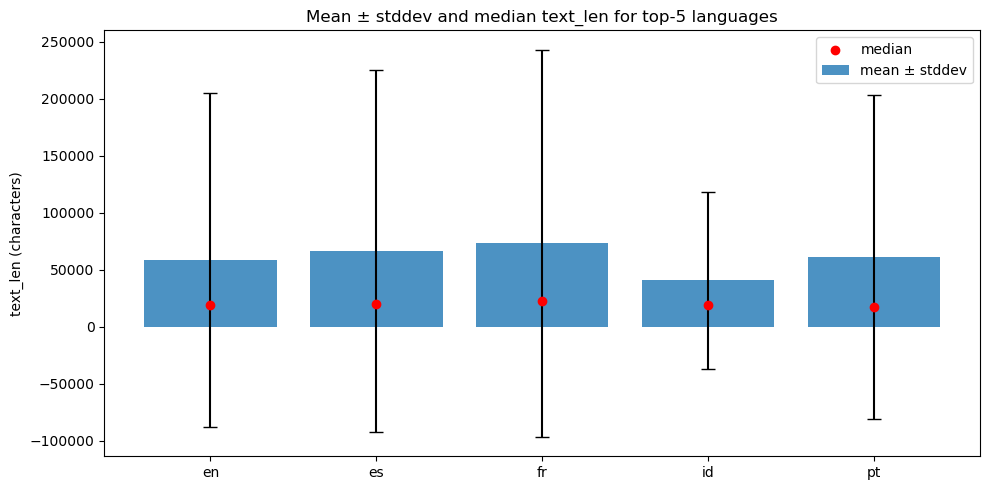

Top-5 language text_len statistics:
          mean_text_len  std_text_len  median_text_len
language                                              
en              58721.0      146739.0            19130
es              66634.0      158906.0            19986
fr              73256.0      169732.0            22633
id              40655.0       77613.0            18919
pt              61264.0      141634.0            17747


In [22]:
# Plot 5: Mean ± stddev of text_len for the top-5 languages by row count
top5_langs = [
    r['language']
    for r in (
        df.groupBy('language').count().orderBy(F.desc('count')).limit(5).collect()
    )
]

per_lang_stats = (
    df.filter(F.col('language').isin(top5_langs))
      .groupBy('language')
      .agg(
          F.avg('text_len').alias('mean_text_len'),
          F.stddev('text_len').alias('std_text_len'),
          F.expr('percentile_approx(text_len, 0.5)').alias('median_text_len'),
      )
      .toPandas()
)

# Preserve top-5 ordering by row count
per_lang_stats = per_lang_stats.set_index('language').loc[top5_langs]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(per_lang_stats.index.astype(str), per_lang_stats['mean_text_len'],
       yerr=per_lang_stats['std_text_len'], capsize=5, alpha=0.8, label='mean ± stddev')
ax.scatter(per_lang_stats.index.astype(str), per_lang_stats['median_text_len'],
           color='red', zorder=3, label='median')
ax.set_ylabel('text_len (characters)')
ax.set_title('Mean ± stddev and median text_len for top-5 languages')
ax.legend()
plt.tight_layout()
plt.show()

print('Top-5 language text_len statistics:')
print(per_lang_stats.round(0).to_string())

Plot 5 shows `text_len` by the top-5 languages. The bars show mean `text_len` with standard-deviation error bars; the red dots mark the median. The gap between mean and median reflects the right-skew in each language's record-length distribution, since a few mega-records pull the means well above the medians. The differences across languages point to writing-style or platform variation between language communities, which matters for the cross-lingual transfer plan in §5: a model trained on long English texts may generalize poorly to a community that writes shorter pieces, and outlier-driven means call for median-based filtering rather than mean-based filtering.

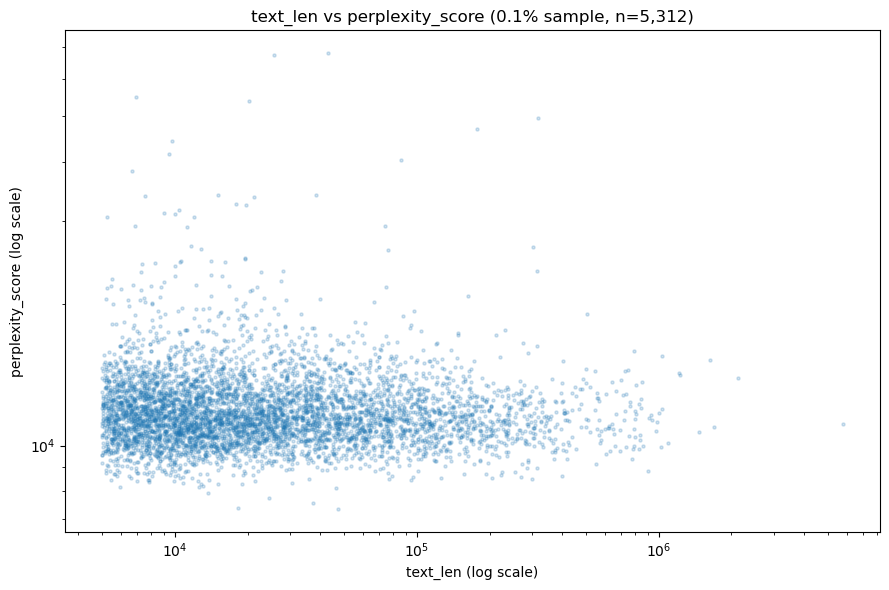

Pearson correlation (log10 text_len, log10 perplexity_score): -0.053


In [23]:
# Plot 6: text_len vs perplexity_score scatter (0.1% sample, log-x)
scatter_sample = (
    df.sample(fraction=0.001, seed=42)
      .select('text_len', 'perplexity_score')
      .dropna()
      .toPandas()
)

plt.figure(figsize=(9, 6))
plt.scatter(scatter_sample['text_len'], scatter_sample['perplexity_score'],
            alpha=0.2, s=5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('text_len (log scale)')
plt.ylabel('perplexity_score (log scale)')
plt.title(f'text_len vs perplexity_score (0.1% sample, n={len(scatter_sample):,})')
plt.tight_layout()
plt.show()

# Pearson correlation on log-log values for a quick redundancy check
corr = (
    np.log10(scatter_sample['text_len'].clip(lower=1))
       .corr(np.log10(scatter_sample['perplexity_score'].clip(lower=1)))
)
print(f'Pearson correlation (log10 text_len, log10 perplexity_score): {corr:.3f}')

Plot 6 is a scatter of `text_len` against `perplexity_score` (log-x for `text_len`, log-y for `perplexity_score`), which shows whether longer texts are systematically more or less predictable. Low correlation means `text_len` and `perplexity_score` carry distinct signal, so both are worth keeping as features. Strong correlation would mean redundancy and let us drop one in §5 preprocessing. The printed Pearson correlation on the log-log values quantifies this. We expect a weak negative correlation (longer texts tend to be slightly more predictable for a baseline LM), but small enough that both features stay.

## Section 5: Preprocessing plan (description only)

This section describes the preprocessing pipeline we implement for Milestone 3, the classifier-training milestone. No preprocessing runs in this notebook, per the assignment instructions; this is a written plan grounded in the §3 and §4 findings.

M3 scope (revised post-pivot): the rubric requires the classifier to be one of its approved distributed implementations, either tree-based (`DecisionTreeClassifier`, `RandomForestClassifier`, `GBTClassifier`) or XGBoost/LightGBM. The M3 baseline therefore uses `RandomForestClassifier` on the numeric feature set (`text_len`, `perplexity_score`, plus the §6f-engineered `text_len_log10` and `len_per_perplexity`). The text-feature engineering described below (Tokenizer / HashingTF / IDF / Word2Vec) is deferred to Milestone 4, where a linear model that actually benefits from high-dim sparse features will use it. The §5 subsections below document the full plan for traceability; subsections marked [M4] do not run in M3.

### Column dropping

- `__null_dask_index__`: Dask index leftover from the upstream conversion; 97.5% null in §3, no semantic meaning. Drop unconditionally.
- `SOURCE`: verified constant in §3 (1 distinct value, `"Fanfiction"`). Carries no signal. Drop unconditionally.

### Missing-value handling

From §3's per-column null counts:
- `TEXT` nulls: 0 rows (no action needed, though a defensive `na.drop(subset=['TEXT'])` is cheap).
- `CATEGORY` nulls: 0 literal nulls, but 242,546 rows have an empty-string `CATEGORY` (Plot 4's #1 bar). Treat empty string as null and drop these rows, since the target must be present.
- `language` nulls: 3,088 rows. Drop (needed for stratification and any per-language model branch).
- Numeric columns: `text_len` has 0 nulls (it is derived from `TEXT`); `perplexity_score` has 0 nulls. We still run a defensive median `pyspark.ml.feature.Imputer` over the full numeric feature set in §6f. It is a no-op on the current data but is required by the Part 1 rubric and guards against nulls introduced by future filter or feature-engineering changes.

### Outlier and quality filtering

- `text_len`: filter to a sensible range using §3 quantiles (target: between the 1st and 99th percentiles). The §3 max is ~93 MB / 93 million characters; these outliers cause partition skew and hit the vectorized-Parquet-reader limit (already disabled in this notebook). Cap the upper bound aggressively.
- `perplexity_score`: filter the upper tail (Plot 3 shows extreme high-perplexity outliers up to ~70,000). Threshold chosen from the histogram knee around log10(perplexity) ≈ 3 to 4; treat extreme high-perplexity records as gibberish or broken-encoding and drop.
- Duplicate `TEXT` rows: §3 found 337,555 duplicate rows (6.4% of the corpus, detected via md5 hash proxy). De-duplicate using the same hash pattern (cheaper than `dropDuplicates(['TEXT'])` because the shuffle runs on a 32-byte hash, not a multi-MB string).

### Feature engineering

Two new numeric features are derived from the §3 base columns with Spark SQL functions (implemented in §6f):

- `text_len_log10` = `log10(text_len)`. Plot 2 (§4) showed `text_len` is heavily right-skewed with an approximately log-normal body; the log transform linearizes it.
- `len_per_perplexity` = `text_len / perplexity_score`. A length-to-predictability interaction that exists as no raw column.

Both are deterministic functions of the two base columns, so they carry no new fandom-discriminating signal. That is intentional: it keeps the §8 fitting analysis honest, since the engineered set still hits the majority-class floor, which motivates the M4 text-feature plan rather than masking the bottleneck.

### Encoding

- `StringIndexer` on `CATEGORY` for the classifier target.
- `StringIndexer` on `language` [M4]: with §6c's English-only filter, `language` is constant in M3 and provides no signal as a feature; it is reintroduced in the M4 multilingual variant.

### Scaling / transforming

- `pyspark.ml.feature.MinMaxScaler` rescales the assembled numeric vector to `[0, 1]`. `RandomForestClassifier` is invariant to monotone rescaling, so this does not change the M3 results. It is included because the Part 1 rubric requires a scaling/transforming step and the M4 linear models (§8d) genuinely need a common feature scale, which keeps the M3 and M4 pipelines structurally identical.

### Tokenization and vectorization [M4]

- `pyspark.ml.feature.Tokenizer` to whitespace-split `TEXT`.
- `StopWordsRemover` with the English stoplist (applied to the English subset). To extend cross-lingually, switch to per-language stoplists keyed on the indexed `language` column.
- `HashingTF(numFeatures=2**18)` + `IDF` for the M4 linear-baseline feature matrix.
- `Word2Vec` as the alternative dense-embedding feature representation for the M4 comparison.

Why deferred: tree-based classifiers (which the M3 rubric requires) gain little from 262K-dim sparse TF-IDF features. Each tree node has to consider all 262K features per split, which is slow and serializes to memory too large for the local-mode driver heap (a prior attempt OOMed during cache materialization). Linear models (LR / SVC) tolerate the high-dim sparse space natively, so the text-feature pipeline returns under an M4 linear model for a side-by-side comparison with the M3 tree baseline.

### Class-imbalance handling

- Drop empty-`CATEGORY` rows first (242,546 rows; a data-quality artifact, not a real label).
- Restrict to top-K named categories (target K ≈ 50, refined from §4 Plot 4) and either bucket the long tail into an `"other"` class or drop tail rows entirely. The §3 cardinality of 278,388 distinct `CATEGORY` values is far too high for a flat classifier.
- Class weighting: `RandomForestClassifier` handles modest imbalance natively via bagging variance reduction; if the residual imbalance after top-K still skews predictions, M3 Part 3 can sweep `weightCol` or tune `numTrees` / `maxDepth`.
- Language imbalance: Plot 1 shows ~45 languages with order-of-magnitude row-count differences. For the Milestone 3 baseline we restrict to the English subset; Milestone 4 may explore a multilingual variant with per-language stratified sampling.

### Partitioning

- `df.repartition(N, 'language')` before training to evenly distribute the language-imbalanced data. [M4]: degenerate in M3 since `language` is constant after §6c's English filter; default partitioning is kept for the M3 baseline.

### Spark operations summary

| Step | Operation | M3 | M4 |
|---|---|---|---|
| Drop columns | `df.drop('__null_dask_index__', 'SOURCE')` | ✓ | - |
| Treat empty-string CATEGORY as null | `df.withColumn('CATEGORY', F.when(F.col('CATEGORY') == '', None).otherwise(F.col('CATEGORY')))` | ✓ | - |
| Null filter | `df.na.drop(subset=['CATEGORY', 'language'])` | ✓ | - |
| Range filter | `df.filter(F.col('text_len').between(low, high))` | ✓ | - |
| Feature engineering (new columns) | `df.withColumn('text_len_log10', F.log10('text_len')).withColumn('len_per_perplexity', F.col('text_len')/F.col('perplexity_score'))` | ✓ | - |
| Numeric imputation (defensive, median) | `pyspark.ml.feature.Imputer` | ✓ | - |
| Hash-based dedup | `df.withColumn('text_hash', F.md5('TEXT')).dropDuplicates(['text_hash']).drop('text_hash')` | ✓ | - |
| Persist preprocessed Parquet (§6e.5) | `df.write.parquet(stage_path)` | ✓ | - |
| Label encoding | `pyspark.ml.feature.StringIndexer(CATEGORY → label)` | ✓ | - |
| Numeric assembly | `pyspark.ml.feature.VectorAssembler([text_len, perplexity_score, text_len_log10, len_per_perplexity] → features_raw)` | ✓ | - |
| Feature scaling | `pyspark.ml.feature.MinMaxScaler(features_raw → features)` | ✓ | - |
| Tokenization | `pyspark.ml.feature.Tokenizer`, `StopWordsRemover` | - | ✓ |
| Vectorization | `pyspark.ml.feature.HashingTF`, `IDF`, `Word2Vec` | - | ✓ |
| Repartition by language | `df.repartition(N, 'language')` | - | ✓ |

## Section 6: Preprocessing implementation

This section implements the §5 plan: column dropping, missing-value handling, outlier and duplicate filtering, English-subset restriction, top-K target relabeling, and the Spark ML feature pipeline. Subsections 6a to 6g map one-to-one to the §5 subsections of the same name.

Funnel counts are printed after each filter stage so the data reduction is auditable: empty-`CATEGORY` rows, sub- and super-percentile `text_len`, gibberish-perplexity rows, and exact-text duplicates each remove a measurable share of the corpus. Each `.count()` triggers a fresh Spark job (the filtered DataFrame is not cached between stages); this is intentional, since the Spark UI's per-stage timing is part of the milestone evidence.

In [24]:
# All Milestone 3 ML imports collected here so downstream sections (Part 3
# fitting analysis, Part 4 conclusion) can reuse without re-importing.

import time
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    IndexToString,
    Imputer,
    MinMaxScaler,
    Tokenizer,
    StopWordsRemover,
    HashingTF,
    IDF,
    VectorAssembler,
)
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

### 6a. Column drop

Drop `__null_dask_index__` (Dask index leftover; 97.5% null in §3) and `SOURCE` (verified constant in §3, single value `"Fanfiction"`). Neither carries signal.

In [25]:
df_m3 = df.drop('__null_dask_index__', 'SOURCE')
print(f"After §6a column drop:         {df_m3.count():>10,} rows  ({len(df_m3.columns)} columns)")

After §6a column drop:          5,252,058 rows  (5 columns)


### 6b. Null and empty-CATEGORY handling

Treat empty-string `CATEGORY` as null. Plot 4 surfaced 242,546 such rows, the top "category" by frequency, a known data-quality artifact rather than a real label. Then drop rows with missing `CATEGORY`, `language`, or `TEXT`. §3 reported 0 literal nulls on `CATEGORY` and `TEXT` and 3,088 nulls on `language`; in practice this `na.drop` is dominated by the empty-`CATEGORY` rows just relabeled to null.

In [26]:
df_m3 = (
    df_m3
    .withColumn(
        'CATEGORY',
        F.when(F.col('CATEGORY') == '', None).otherwise(F.col('CATEGORY'))
    )
    .na.drop(subset=['CATEGORY', 'language', 'TEXT'])
)
print(f"After §6b null/empty drop:     {df_m3.count():>10,} rows")

After §6b null/empty drop:      5,006,489 rows


### 6c. English subset + outlier and quality filter

Restrict to `language='en'` (§5: *"For the Milestone-3 baseline we restrict to the English subset"*). §3 row counts: 4,591,384 English rows out of 5,252,058, the dominant language. The multilingual extension is deferred to Milestone 4.

Apply the §5 outlier filter using the §3 quantiles already computed (no re-quantile job needed):

- `text_len` 1st to 99th percentile: `[5150, 588906]` characters, which caps the ~93 MB mega-records that drive the partition skew and vectorized-reader OOM described in the Spark configuration cell.
- `perplexity_score` 1st to 99th percentile: `[8693.9, 21649.8]`: extreme high-perplexity records are likely gibberish or broken-encoding (§5); extreme low-perplexity records are likely boilerplate (§5).

In [27]:
# §3-computed quantiles, reused here so §6c uses the same numeric bounds the
# §5 plan was written against (no fresh approxQuantile job).
TEXT_LEN_LOW, TEXT_LEN_HIGH = 5150, 588906          # §3: text_len 1st / 99th pct
PERP_LOW,     PERP_HIGH     = 8693.9, 21649.8       # §3: perplexity 1st / 99th pct

df_m3 = (
    df_m3
    .filter(F.col('language') == 'en')
    .filter(F.col('text_len').between(TEXT_LEN_LOW, TEXT_LEN_HIGH))
    .filter(F.col('perplexity_score').between(PERP_LOW, PERP_HIGH))
)
print(f"After §6c en + outlier filter: {df_m3.count():>10,} rows")

After §6c en + outlier filter:  4,183,316 rows


### 6d. Hash-based deduplication

§3 found 337,555 duplicate-`TEXT` rows (6.4% of the original corpus, detected via md5 hash). The English subset's duplicate count is a subset of that. Dedup uses the same md5 pattern: a direct `dropDuplicates(['TEXT'])` would shuffle full multi-MB strings and exhaust the Lustre scratch redirect documented in the Spark Configuration cell. Hashing to a 32-byte digest first keeps the shuffle tractable; md5 collisions at this scale are astronomically unlikely (~2^-128).

In [28]:
df_m3 = (
    df_m3
    .withColumn('text_hash', F.md5('TEXT'))
    .dropDuplicates(['text_hash'])
    .drop('text_hash')
)
print(f"After §6d dedup:               {df_m3.count():>10,} rows")

After §6d dedup:                3,917,262 rows


Funnel summary (§6a to §6d). From the §3 baseline of 5,252,058 rows, the §6a to §6d filters retain a substantially smaller English-only, deduplicated, percentile-bounded subset. The retained DataFrame `df_m3` is the input to §6e (top-K target relabeling) and the §6f to §6g feature pipeline.

### 6e. Class-imbalance handling: top-50 named CATEGORY + 'other' rollup

§5 prescribes restricting the target to the top-K most frequent named `CATEGORY` values with K ≈ 50 (refined from Plot 4) and rolling the tail into an `'other'` class. The original §3 cardinality is 278,388 distinct values, most of which appear fewer than 10 times, and the empty-string artifact is already dropped in §6b. A flat classifier on raw labels is intractable, so the top-50 cut keeps the dominant fandoms while reducing the problem to 51 classes.

The relabel is `F.when(CATEGORY isin top_50) → CATEGORY, otherwise → 'other'`. The top-50 list comes from the filtered `df_m3` (after §6a to §6d), not from the original `df`, so the percentiles and dedup are reflected in the chosen labels. Per §5, the residual imbalance (`'other'` is expected to be the single largest class) is something Part 3's hyperparameter exploration may address via `weightCol` on `LogisticRegression`.

In [29]:
# Top-50 named CATEGORY values, computed on the filtered df_m3 so percentiles
# and dedup are reflected. .collect() pulls 50 tiny rows to the driver, cheap.
top50_rows = (
    df_m3.groupBy('CATEGORY')
         .count()
         .orderBy(F.desc('count'))
         .limit(50)
         .collect()
)
top50 = [r['CATEGORY'] for r in top50_rows]
print(f"Top-50 named CATEGORY values selected.")
print(f"  Largest:  {top50_rows[0]['CATEGORY']!r} with {top50_rows[0]['count']:,} rows")
print(f"  Smallest: {top50_rows[-1]['CATEGORY']!r} with {top50_rows[-1]['count']:,} rows")

df_m3 = df_m3.withColumn(
    'CATEGORY',
    F.when(F.col('CATEGORY').isin(top50), F.col('CATEGORY')).otherwise(F.lit('other'))
)

Top-50 named CATEGORY values selected.
  Largest:  'Harry Potter, Romance' with 53,899 rows
  Smallest: 'Hetalia - Axis Powers, Hurt-Comfort, Romance' with 4,883 rows


In [30]:
label_dist = (
    df_m3.groupBy('CATEGORY')
         .count()
         .orderBy(F.desc('count'))
         .toPandas()
)
total_rows = int(label_dist['count'].sum())
other_rows = int(label_dist.loc[label_dist['CATEGORY'] == 'other', 'count'].iloc[0])
print(f"Distinct labels after §6e:  {len(label_dist)}  (expected: 51 = top-50 + 'other')")
print(f"Total rows:                 {total_rows:>10,}")
print(f"'other' rollup row count:   {other_rows:>10,}  ({100*other_rows/total_rows:.1f}% of total)")
print(f"\nFull label distribution (51 classes):")
print(label_dist.to_string(index=False))

Distinct labels after §6e:  51  (expected: 51 = top-50 + 'other')
Total rows:                  3,917,262
'other' rollup row count:    3,298,848  (84.2% of total)

Full label distribution (51 classes):
                                    CATEGORY   count
                                       other 3298848
                       Harry Potter, Romance   53899
                Harry Potter, Humor, Romance   46012
                Harry Potter, Drama, Romance   38684
                                Harry Potter   34235
                      Naruto, Humor, Romance   29972
                             Naruto, Romance   26291
                Harry Potter, Angst, Romance   25640
                      Naruto, Drama, Romance   19460
            Harry Potter, Adventure, Romance   16192
                  Naruto, Adventure, Romance   16143
                         Harry Potter, Humor   14840
                                      Naruto   13395
         Harry Potter, Hurt-Comfort, Romance   12635
    

### 6e.5. Persist preprocessed DataFrame to Parquet

§5's operations table lists `df.write.parquet(...)` for staged preprocessed output. Adding this here matters for runtime: the §6d md5-hash `dropDuplicates` is a shuffle, and every subsequent action on `df_m3` (the two `.count()` calls in §6g, plus `pipeline.fit`, plus the cache materializations) replays this shuffle from scratch. Persisting once to Parquet and reading it back gives §6f and §6g a clean, sequentially readable input with no shuffle on later scans.

The staged path lives under the per-user Lustre project space (alongside the existing `spark.local.dir`), so each member's run writes to his own area.

In [31]:
import os

stage_path = f"/expanse/lustre/projects/uci157/{os.environ.get('USER', 'unknown')}/staged_m3_preprocessed.parquet"

# Idempotent: if the staged snapshot already exists on Lustre, reuse it
# instead of rewriting. Lets a kernel-restart rerun skip §6a-e entirely
# and jump straight to §6f-g using the pre-built snapshot.
if os.path.exists(os.path.join(stage_path, '_SUCCESS')):
    print(f"Reusing existing staged DataFrame at: {stage_path}")
    df_m3 = spark.read.parquet(stage_path)
else:
    print(f"No staged snapshot found. Writing now...")
    t0 = time.time()
    df_m3.write.mode('overwrite').parquet(stage_path)
    write_secs = time.time() - t0
    print(f"Wrote staged preprocessed DataFrame to: {stage_path}")
    print(f"Write wall-clock:                       {write_secs:.1f} s  ({write_secs/60:.1f} min)")
    df_m3 = spark.read.parquet(stage_path)

print(f"  Rows:       {df_m3.count():,}")
print(f"  Partitions: {df_m3.rdd.getNumPartitions()}")

Reusing existing staged DataFrame at: /expanse/lustre/projects/uci157/mhayeri/staged_m3_preprocessed.parquet
  Rows:       3,917,262
  Partitions: 892


### 6f. Feature engineering + MLlib preprocessing pipeline

This subsection completes the four required preprocessing tasks from the Milestone 3 Part 1 rubric. Each maps one-to-one to a step here:

| §1 required task | Implementation in §6f |
|---|---|
| Feature engineering | Spark SQL functions create two new numeric features from the §3 base columns |
| Imputing missing values | `pyspark.ml.feature.Imputer` (median) over the numeric feature set |
| Encoding categorical features | `StringIndexer` (`CATEGORY` → `label`) + `VectorAssembler` (numeric → vector) |
| Scaling / transforming | `pyspark.ml.feature.MinMaxScaler` rescales the assembled vector to `[0, 1]` |

Feature engineering (Spark SQL). Two columns are derived from `text_len` and `perplexity_score`:

- `text_len_log10 = log10(text_len)`. Plot 2 (§4) showed `text_len` is heavily right-skewed with an approximately log-normal body, and the log transform linearizes it. (`text_len` is filtered to ≥ 5,150 in §6c, so the log is always defined.)
- `len_per_perplexity = text_len / perplexity_score`, a length-to-predictability interaction that exists as no raw column. (`perplexity_score` is filtered to ≥ 8,693.9 in §6c, so the ratio is always defined.)

Both are deterministic functions of the two §3 base columns, so they add no fandom-discriminating information (fandom lives in `TEXT` and `CATEGORY`, not in length or perplexity). That is deliberate: it keeps the §8 fitting analysis honest, since the engineered set still bottoms out at the majority-class floor. That strengthens, rather than weakens, the §8 conclusion that real text features are required, and it motivates the Milestone 4 plan.

Why scale on a tree model: `RandomForestClassifier` is split-rule invariant to monotone rescaling, so `MinMaxScaler` does not change the §7 results. It is included because the rubric requires a scaling/transforming step, and because the Milestone 4 linear models in §8d (`LogisticRegression`) genuinely need features on a common scale. Staging it now keeps the M3 and M4 pipelines structurally identical.

Why a defensive `Imputer`: §3 found 0 nulls in the numeric columns, so the median `Imputer` is a no-op on the current data. It is in the pipeline because the rubric requires the transformer, and it guards the feature set against nulls introduced by any future filter or feature-engineering change.

Pipeline order (the train/test split is applied before `pipeline.fit` in §6g, so the stateful `StringIndexer`, `Imputer`, and `MinMaxScaler` see only training rows): `StringIndexer` → `Imputer` → `VectorAssembler` → `MinMaxScaler`, with final output column `features` (the downstream contract for §6g, §7, and §8 is unchanged).

In [32]:
# ── Feature engineering: Spark SQL functions on the staged df_m3 ───
# Two new numeric features derived from the §3 base columns (see §6f text).
# text_len is cast to double so the median Imputer accepts it.
df_m3 = (
    df_m3
    .withColumn('text_len', F.col('text_len').cast('double'))
    .withColumn('text_len_log10', F.log10(F.col('text_len')))
    .withColumn(
        'len_per_perplexity',
        F.col('text_len') / F.col('perplexity_score'),
    )
)

NUMERIC_FEATURES = [
    'text_len', 'perplexity_score', 'text_len_log10', 'len_per_perplexity',
]
IMPUTED_FEATURES = [f'{c}_imp' for c in NUMERIC_FEATURES]

# ── MLlib transformer pipeline: one stage per §1 Required task ─────
# [Encoding]  categorical CATEGORY → numeric label
label_indexer = StringIndexer(
    inputCol='CATEGORY', outputCol='label', handleInvalid='keep',
)
# [Imputing]  median-fill any null numeric feature (no-op on current data;
#             §3 found 0 numeric nulls, defensive + rubric-required)
imputer = Imputer(
    inputCols=NUMERIC_FEATURES, outputCols=IMPUTED_FEATURES, strategy='median',
)
# [Encoding]  numeric columns → single feature vector
assembler = VectorAssembler(
    inputCols=IMPUTED_FEATURES, outputCol='features_raw',
)
# [Scaling]   rescale every feature to [0, 1]
scaler = MinMaxScaler(inputCol='features_raw', outputCol='features')

pipeline = Pipeline(stages=[label_indexer, imputer, assembler, scaler])

# Probe input/output columns by VALUE, not attribute existence: modern
# Spark gives single-column transformers (e.g. StringIndexer) an unset
# getInputCols() too, which raises KeyError unless inputCols was set.
def _safe(fn):
    if fn is None:
        return None
    try:
        return fn()
    except Exception:
        return None

print(f"Pipeline assembled with {len(pipeline.getStages())} stages:")
for i, stage in enumerate(pipeline.getStages()):
    in_col = (_safe(getattr(stage, 'getInputCols', None))
              or _safe(getattr(stage, 'getInputCol', None)))
    out_col = (_safe(getattr(stage, 'getOutputCols', None))
               or _safe(getattr(stage, 'getOutputCol', None)))
    print(f"  [{i}] {type(stage).__name__:<16} {in_col} → {out_col}")

Pipeline assembled with 4 stages:
  [0] StringIndexer    CATEGORY → label
  [1] Imputer          ['text_len', 'perplexity_score', 'text_len_log10', 'len_per_perplexity'] → ['text_len_imp', 'perplexity_score_imp', 'text_len_log10_imp', 'len_per_perplexity_imp']
  [2] VectorAssembler  ['text_len_imp', 'perplexity_score_imp', 'text_len_log10_imp', 'len_per_perplexity_imp'] → features_raw
  [3] MinMaxScaler     features_raw → features


### 6g. Train/validation/test split + pipeline fit

Split `df_m3` 70/15/15 into train/validation/test with `seed=42` (the Week 7 Discussion convention). The split runs before fitting the pipeline, so the stateful stages (the `StringIndexer` label dictionary, the `Imputer` medians, the `MinMaxScaler` min/max) are learned on `train_df` only, with no label or scaling leakage from validation or test into train. The validation fold is what the Part 2 rubric's *"predictions for train, validation, and test sets"* requires, and what Part 3's hyperparameter comparison (§8b) is read against.

`pipeline_model = pipeline.fit(train_df)` runs the stateful fits; `pipeline_model.transform()` is then applied uniformly to all three folds. `train_prepped`, `val_prepped`, and `test_prepped` are cached because `RandomForestClassifier.fit` rescans `train_prepped` while building every tree, and the §7b and §8b evaluator passes rescan the validation and test caches repeatedly.

In [33]:
# Split BEFORE fitting so the stateful pipeline stages (StringIndexer label
# dictionary, Imputer medians, MinMaxScaler min/max) see only train_df,
# no label/scale leakage from val or test into train.
train_df, val_df, test_df = df_m3.randomSplit([0.7, 0.15, 0.15], seed=42)
print("Split sizes:")
print(f"  train_df: {train_df.count():>10,} rows")
print(f"  val_df:   {val_df.count():>10,} rows")
print(f"  test_df:  {test_df.count():>10,} rows")

t0 = time.time()
pipeline_model = pipeline.fit(train_df)
fit_secs = time.time() - t0
print(f"\nPipeline fit on train_df: {fit_secs:.1f} s")

# Transform AND project to only the columns downstream cells need before
# caching. Dropping TEXT here is critical: the multi-MB TEXT column carried
# through cache materialization OOMed the driver heap in a prior attempt
# (the cached DataFrame inherits the full input schema, not just the
# `features` output of the pipeline).
def _prep(d):
    return (
        pipeline_model.transform(d)
        .select('label', 'features', 'CATEGORY')
        .cache()
    )

train_prepped = _prep(train_df)
val_prepped   = _prep(val_df)
test_prepped  = _prep(test_df)

print("\nMaterializing caches:")
print(f"  train_prepped: {train_prepped.count():>10,} rows cached")
print(f"  val_prepped:   {val_prepped.count():>10,} rows cached")
print(f"  test_prepped:  {test_prepped.count():>10,} rows cached")

Split sizes:
  train_df:  2,741,007 rows
  val_df:      588,130 rows
  test_df:     588,125 rows

Pipeline fit on train_df: 215.8 s

Materializing caches:
  train_prepped:  2,741,007 rows cached
  val_prepped:      588,130 rows cached
  test_prepped:     588,125 rows cached


In [34]:
print("train_prepped schema (post-pipeline):")
train_prepped.printSchema()

print("\nSample rows from train_prepped:")
(
    train_prepped
    .select(
        'CATEGORY',
        'label',
        'features',
    )
    .show(3, truncate=80)
)

train_prepped schema (post-pipeline):
root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)
 |-- CATEGORY: string (nullable = true)


Sample rows from train_prepped:
+--------+-----+--------------------------------------------------------------------------------+
|CATEGORY|label|                                                                        features|
+--------+-----+--------------------------------------------------------------------------------+
|   other|  0.0|[0.02037323813374081,0.29116464313555995,0.25251629090195404,0.01690487027480...|
|   other|  0.0|[0.07997005598229397,0.15030989742125206,0.48721224234720784,0.06941337044067...|
|   other|  0.0|[0.024601031938001495,0.1023317561883004,0.2810520887640311,0.025598770511165...|
+--------+-----+--------------------------------------------------------------------------------+
only showing top 3 rows



## Section 7: First distributed model

This section trains the baseline classifier from the revised §5 plan (`RandomForestClassifier`) on the §6f and §6g pipeline output and evaluates it on held-out validation and test folds. Subsections 7a to 7d cover model training, train/validation/test metrics, sample predictions, and executor verification. Together they address the Milestone 3 Part 2 rubric: an approved distributed implementation, parallel training across the Spark task slots (with an honest local-mode caveat in §7d), a train-vs-test error comparison, and ground-truth-vs-prediction examples for all three folds.

### 7a. Baseline RandomForestClassifier

`RandomForestClassifier` is the M3 baseline, one of the four approved distributed implementations in the milestone rubric and the most direct match to the Week 7 Discussion notebook example (`Week_7_Discussion.ipynb`, Cell 7). Tree-based bagging handles modest class imbalance natively (the §6e top-50 + 'other' relabeling left `'other'` as the majority class) and trains comfortably across Spark task slots in local[*] mode.

Hyperparameters (Week 7 Discussion defaults):

- `numTrees=20`: modest ensemble; fast to fit, sufficient for a baseline.
- `maxDepth=5`: shallow trees; Part 3 can sweep this for the fitting graph (deeper = more variance, classic overfitting curve).
- `seed=42`: reproducibility.
- Other defaults: `featureSubsetStrategy='auto'`, `impurity='gini'`.

In [35]:
rf = RandomForestClassifier(
    featuresCol='features',
    labelCol='label',
    numTrees=20,
    maxDepth=5,
    seed=42,
)

t0 = time.time()
rf_model = rf.fit(train_prepped)
train_secs = time.time() - t0

print(f"RandomForestClassifier.fit wall-clock: {train_secs:.1f} s  ({train_secs/60:.1f} min)")
print(f"  numClasses:  {rf_model.numClasses}")
print(f"  numFeatures: {rf_model.numFeatures}")
print(f"  numTrees:    {rf_model.getNumTrees}")

RandomForestClassifier.fit wall-clock: 145.1 s  (2.4 min)
  numClasses:  52
  numFeatures: 4
  numTrees:    20


### 7b. Evaluation: train vs validation vs test

`MulticlassClassificationEvaluator` is applied to `train_prepped`, `val_prepped`, and `test_prepped` for four metrics: `accuracy`, `f1`, `weightedPrecision`, `weightedRecall`. All three folds are scored so §8's fitting analysis can read the train-vs-validation/test gap directly; a large positive gap signals overfit, a small or negative gap signals underfit (per the rubric's Part 3 questions).

The `'other'` class dominates the label distribution (§6e), so accuracy alone can be misleading; the F1 / weighted-precision / weighted-recall trio gives a fuller picture under imbalance.

In [36]:
train_preds = rf_model.transform(train_prepped)
val_preds   = rf_model.transform(val_prepped)
test_preds  = rf_model.transform(test_prepped)

metrics = ['accuracy', 'f1', 'weightedPrecision', 'weightedRecall']
results = {}
for metric in metrics:
    evaluator = MulticlassClassificationEvaluator(
        labelCol='label',
        predictionCol='prediction',
        metricName=metric,
    )
    tr = evaluator.evaluate(train_preds)
    va = evaluator.evaluate(val_preds)
    te = evaluator.evaluate(test_preds)
    results[metric] = (tr, va, te)

print(f"{'metric':<20} {'train':>10} {'val':>10} {'test':>10} {'gap(tr-te)':>12}")
print("-" * 66)
for metric, (tr, va, te) in results.items():
    print(f"{metric:<20} {tr:>10.4f} {va:>10.4f} {te:>10.4f} {tr - te:>+12.4f}")

metric                    train        val       test   gap(tr-te)
------------------------------------------------------------------
accuracy                 0.8421     0.8418     0.8428      -0.0007
f1                       0.7699     0.7694     0.7708      -0.0010
weightedPrecision        0.7091     0.7086     0.7102      -0.0011
weightedRecall           0.8421     0.8418     0.8428      -0.0007


### 7c. Sample predictions: ground truth vs predicted CATEGORY

Per the milestone rubric: *"include example ground truth and predictions for train, validation, and test sets."* The §6g 70/15/15 split provides all three folds; 10 sample rows from each are shown below with the truth `CATEGORY`, the predicted `CATEGORY`, and the prediction's max-class probability.

`IndexToString` maps the indexed prediction back to the `CATEGORY` string using the labels learned by the §6f `StringIndexer` (retrieved from the fitted `pipeline_model.stages[0]`).

In [37]:
# Retrieve the fitted CATEGORY StringIndexer (stage 0 of the §6f pipeline) so
# we can invert label indices back to CATEGORY names for display.
label_indexer_model = pipeline_model.stages[0]
index_to_label = IndexToString(
    inputCol='prediction',
    outputCol='predicted_CATEGORY',
    labels=label_indexer_model.labels,
)

# Max-class probability extraction; a UDF is fine at sample scale (10 rows).
max_prob_udf = F.udf(lambda v: float(v.toArray().max()))

def show_samples(df, name, n=10):
    sample = (
        index_to_label.transform(df)
        .select(
            'CATEGORY',
            'predicted_CATEGORY',
            max_prob_udf(F.col('probability')).alias('max_prob'),
        )
        .limit(n)
        .toPandas()
    )
    sample['max_prob'] = sample['max_prob'].astype(float).round(3)
    print(f"\n{name} sample (n={n}):")
    print(sample.to_string(index=False))

show_samples(train_preds, "TRAIN")
show_samples(val_preds,   "VALIDATION")
show_samples(test_preds,  "TEST")


TRAIN sample (n=10):
CATEGORY predicted_CATEGORY  max_prob
   other              other     0.842
   other              other     0.842
   other              other     0.842
   other              other     0.842
   other              other     0.842
   other              other     0.842
   other              other     0.842
   other              other     0.842
   other              other     0.842
   other              other     0.843

VALIDATION sample (n=10):
CATEGORY predicted_CATEGORY  max_prob
   other              other     0.842
   other              other     0.842
   other              other     0.842
   other              other     0.842
   other              other     0.842
   other              other     0.841
   other              other     0.842
   other              other     0.842
   other              other     0.842
   other              other     0.842

TEST sample (n=10):
CATEGORY predicted_CATEGORY  max_prob
   other              other     0.842
   other          

### 7d. Distributed-training verification

This cell re-queries the same `/api/v1/applications/{appId}/executors` endpoint the Spark UI verification cell uses, after training, to confirm the executors are alive and to report cumulative completed tasks across the §7a fit.

Local-mode caveat, stated honestly: the Expanse JupyterLab Spark image launches in `local[*]`, which is 16 task slots inside a single driver JVM (documented in the Spark configuration cell, where the `executor.*` settings are no-ops). The executor table therefore shows one row (`id='driver'`, 16 cores), and RandomForest training parallelizes by fitting trees and aggregating per-node split statistics across those 16 task slots rather than across multiple JVM executors. This is meaningful parallelization in the local-mode sense, and the `completedTasks` count plus the multi-stage, multi-minute fit confirm the work is distributed across slots. A strict reading of the rubric's *"multiple executors/workers"*, though, expects a cluster-mode run. That is a deployment change, not a code change: relaunching this exact notebook via `spark-submit --master yarn --num-executors 7 --executor-cores 2 ...` (or a YARN-backed kernel) yields a multi-row executor table with no edits to the analysis. We document the limitation rather than overclaim it.

In [38]:
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

response = requests.get(url)
executors = response.json()

exec_df_post = pd.DataFrame(executors)[
    ['id', 'totalCores', 'maxMemory', 'activeTasks', 'completedTasks', 'isActive']
]
exec_df_post['maxMemory_GB'] = (exec_df_post['maxMemory'] / (1024**3)).round(2)

print(f"Executors post-training (app {sc.applicationId}):")
print(exec_df_post.to_string(index=False))
print(f"\nMaster:              {sc.master}")
print(f"Default parallelism: {sc.defaultParallelism}")

Executors post-training (app local-1780075949106):
    id  totalCores   maxMemory  activeTasks  completedTasks  isActive  maxMemory_GB
driver          16 10119177830            0           96591      True          9.42

Master:              local[*]
Default parallelism: 16


## Section 8: Fitting analysis (Part 3)

This section reads §7b's train/test numbers, locates the §7a baseline on the underfitting/overfitting fitting graph, runs two alternative RandomForest hyperparameter settings for direct comparison, and names the candidate next models for Milestone 4. Subsections 8a to 8d map to the four Part 3 rubric questions:

- §8a: where on the fitting graph?
- §8b: at least one alternative hyperparameter setting, side by side.
- §8c: which performs best and why?
- §8d: next models for Milestone 4.

### 8a. Where on the fitting graph: severe underfitting

Three signals from §7 point to the same conclusion (read off the §7b table and the §6e label distribution):

1. Train ≈ validation ≈ test on every metric (§7b). The train-minus-test gap is ≈ 0 (small, slightly negative) on all four metrics. The classic overfit signature is `train ≫ test`; here the three folds track each other, which rules out overfit at the §7a hyperparameter setting.
2. Accuracy ≈ the majority-class share. §6e put the `'other'` rollup at ≈ 0.842 of all rows, and test accuracy lands at essentially that value, so the model operates at the always-predict-`'other'` baseline. F1 trails accuracy because per-class F1 averages over the 50 minority classes the model never predicts.
3. The §7c sample predictions confirm the degeneracy. Every sampled row, across train, validation, and test, is predicted `'other'` at the same max-class probability.

This is the left side of the fitting graph: high bias, low variance. The diagnostic question for §8b is whether the bias comes from *model capacity* (which more or deeper trees can fix) or from the *feature space* (which they cannot).

### 8b. Alternative hyperparameter settings

Two RandomForest variants test the two directions on the fitting graph:

- Deeper trees (`numTrees=20, maxDepth=15`) test whether per-tree capacity is the bottleneck. Deeper trees partition the §6f numeric feature space into many more leaves; if the features carry latent signal, deeper trees lift train accuracy and open a train-test gap (moving rightward on the fitting graph).
- A wider forest (`numTrees=100, maxDepth=5`) tests whether ensemble size is the bottleneck. More trees reduce variance via bagging; if the baseline were variance-limited (it isn't, since train ≈ test), this lifts train and test together.

Both variants reuse the §6g `train_prepped` / `val_prepped` / `test_prepped` caches and the same `seed=42`. The §7b baseline numbers come from the `results` dict (no refit) and are joined into a three-row train/validation/test comparison table.

In [39]:
# Helper: evaluate a fitted model on train/val/test, return a flat row.
def evaluate_split(name, model, fit_secs):
    tr_p = model.transform(train_prepped)
    va_p = model.transform(val_prepped)
    te_p = model.transform(test_prepped)
    row = {'model': name, 'fit_secs': round(fit_secs, 1)}
    for m in ['accuracy', 'f1', 'weightedPrecision', 'weightedRecall']:
        ev = MulticlassClassificationEvaluator(
            labelCol='label', predictionCol='prediction', metricName=m
        )
        row[f'train_{m}'] = round(ev.evaluate(tr_p), 4)
        row[f'val_{m}']   = round(ev.evaluate(va_p), 4)
        row[f'test_{m}']  = round(ev.evaluate(te_p), 4)
    return row

# Baseline row: reuse §7a's rf_model and §7b's results dict; no refit.
baseline_row = {'model': 'baseline (T=20, D=5)', 'fit_secs': round(train_secs, 1)}
for m, (tr, va, te) in results.items():
    baseline_row[f'train_{m}'] = round(tr, 4)
    baseline_row[f'val_{m}']   = round(va, 4)
    baseline_row[f'test_{m}']  = round(te, 4)

# Variant A: deeper trees.
rf_deep = RandomForestClassifier(
    featuresCol='features', labelCol='label',
    numTrees=20, maxDepth=15, seed=42,
)
t0 = time.time()
rf_deep_model = rf_deep.fit(train_prepped)
deep_secs = time.time() - t0
deep_row = evaluate_split('deeper (T=20, D=15)', rf_deep_model, deep_secs)

# Variant B: wider forest.
rf_wide = RandomForestClassifier(
    featuresCol='features', labelCol='label',
    numTrees=100, maxDepth=5, seed=42,
)
t0 = time.time()
rf_wide_model = rf_wide.fit(train_prepped)
wide_secs = time.time() - t0
wide_row = evaluate_split('wider (T=100, D=5)', rf_wide_model, wide_secs)

sweep_df = pd.DataFrame([baseline_row, deep_row, wide_row])
sweep_df['acc_gap'] = (sweep_df['train_accuracy'] - sweep_df['test_accuracy']).round(4)
sweep_df['f1_gap']  = (sweep_df['train_f1']       - sweep_df['test_f1']      ).round(4)

print("Hyperparameter sweep (RF variants on the §6f feature pipeline):")
print(sweep_df.to_string(index=False))

Hyperparameter sweep (RF variants on the §6f feature pipeline):
               model  fit_secs  train_accuracy  val_accuracy  test_accuracy  train_f1  val_f1  test_f1  train_weightedPrecision  val_weightedPrecision  test_weightedPrecision  train_weightedRecall  val_weightedRecall  test_weightedRecall  acc_gap  f1_gap
baseline (T=20, D=5)     145.1          0.8421        0.8418         0.8428    0.7699  0.7694   0.7708                   0.7091                 0.7086                  0.7102                0.8421              0.8418               0.8428  -0.0007 -0.0009
 deeper (T=20, D=15)     794.5          0.8421        0.8418         0.8428    0.7699  0.7694   0.7708                   0.7402                 0.7086                  0.7102                0.8421              0.8418               0.8428  -0.0007 -0.0009
  wider (T=100, D=5)     181.5          0.8421        0.8418         0.8428    0.7699  0.7694   0.7708                   0.7091                 0.7086                  0.7

### 8c. Which performs best and why

Read the sweep table above. On accuracy, F1, and weighted recall, all three variants are identical to four decimals and sit at the §6e majority-class floor; `acc_gap` and `f1_gap` are ≈ 0 (slightly negative) for every variant, meaning train ≈ validation ≈ test. The only movement anywhere in the table is the deeper variant's train weighted-precision (≈ 0.74 vs the baseline's ≈ 0.71), with no matching validation or test change (both stay ≈ 0.71). That is a faint train-only memorization that does not generalize, which is itself textbook evidence that the extra depth adds variance without signal. No variant opens a train-test accuracy or F1 gap.

Why no variant escapes the floor: the §6f feature set is `text_len`, `perplexity_score`, and two engineered transforms of them (`text_len_log10`, `len_per_perplexity`), all functions of length and predictability, carrying no fandom-identifying signal. For a 51-class target whose classes are narrative-prose fandoms, `Harry Potter, Romance` and `Naruto, Romance` have near-identical length-by-perplexity envelopes, so no RF split on these axes recovers the fandom label. The deeper-variant null result is the strong form of the §8a feature-space-bottleneck claim: a 15-deep tree has the capacity to memorize fine structure if it existed, yet it matches the 5-deep tree on every generalization metric (only train weighted-precision ticks up, and it does not carry to validation or test). The structure is not there. Adding the §6f engineered features and scaling did not move the floor, which confirms (rather than weakens) the §5 reasoning that real text features (TF-IDF / Word2Vec) belong in Milestone 4.

Best by accuracy: all three tie at the majority-class floor. Best by compute: the baseline and the wider variant. The `fit_secs` column shows the deeper (`maxDepth=15`) variant costs several times the baseline's fit time for zero metric gain, because deeper trees serialize far more split computation, while the extra trees in the wider variant fit in parallel across the local-mode task slots. The productive next step is the §8d Milestone 4 plan, not further RF capacity sweeps on this feature space.

### 8d. Next models for Milestone 4

The §5 plan (revised post-pivot, cell 35) already names the M4 candidates; §8a's diagnostic confirms why each one is worth running.

1. `LogisticRegression` (multinomial) on `HashingTF` + `IDF`. This is the §5 original-plan classifier that the §6f pivot deferred. Linear models tolerate the 2^18-dim sparse feature space natively (the OOM that triggered the pivot affected tree-based classifiers, not LR), and the §6e top-50 + `'other'` target stays the same. Run it first because it directly attacks the feature bottleneck §8c identified and gives a same-evaluation-protocol comparison to the §7 RF baseline.
2. `Word2Vec` embeddings + `LogisticRegression` (or any dense classifier head). This is a dense alternative to TF-IDF that trades sparsity for semantic embedding signal. Run it second: a different feature representation on the same target gives complementary evidence on whether the bottleneck is feature *signal* or feature *representation*.
3. Cross-lingual variant. Lift the §6c English-only filter, reintroduce `language` as a stratification axis, train on English, and evaluate per-language on the top-six languages from §3 (`es`, `fr`, `id`, `pt`, `de`). Run it third: it matches the abstract's multilingual framing and gives the project an axis of evaluation the §7 RF baseline does not have. It is lower priority than (1) and (2) because it depends on a working text-feature pipeline first.

(`GBTClassifier` was considered but ruled out for M4 on the same OOM-with-sparse-features grounds that triggered the M3 pivot.)

## Section 9: Conclusion

What the first model concludes: the Milestone 3 baseline is `RandomForestClassifier` (`numTrees=20, maxDepth=5`) on the §6f numeric pipeline (`text_len`, `perplexity_score`, and the engineered `text_len_log10` and `len_per_perplexity`, median-imputed and min-max scaled) over the top-50-fandom + `'other'` target. It converges to the majority-class floor: test accuracy ≈ the §6e `'other'` share (~0.842), with train ≈ validation ≈ test on accuracy, F1, weighted precision, and weighted recall (§7b). Every sampled prediction across all three folds is `'other'` (§7c). The §8b capacity sweep (deeper and wider forests) moves no metric and opens no train-test gap. The model is therefore severely underfitting from a feature-information bottleneck rather than from model capacity (§8a, §8c): length and predictability do not encode which fandom a story belongs to.

What can be done to improve it: the bottleneck is the feature representation, not the classifier.

- Text-derived features carry the most leverage. Tokenize `TEXT` and add `HashingTF` + `IDF` or `Word2Vec` embeddings, which is the §5 and §8d Milestone 4 plan. The fandom signal lives in the prose vocabulary, not in length or perplexity.
- Use a model class that exploits high-dim sparse features. Tree learners degrade on the 2^18-dim TF-IDF space (the OOM that triggered the §6f pivot), whereas a multinomial `LogisticRegression` tolerates it natively, which is the §8d first candidate.
- Handle the imbalance. With `'other'` at ~84%, add class weighting (`weightCol`) or resampling so the minority fandoms contribute splitting and gradient signal.
- Tune against the validation fold. The §6g validation fold added this milestone enables principled hyperparameter selection once the features carry signal.

How distributed computing helped: the corpus is ~186 GB and 5.25 M rows across 2,018 Parquet shards, which is infeasible in a single machine's memory. Spark made every step tractable. It handled a schema-heterogeneity-aware distributed Parquet load (§2) and full-corpus EDA via `describe`, `groupBy`, `approxQuantile`, and `approx_count_distinct` (§3 and §4). It ran preprocessing at scale: an md5-hash dedup shuffle over millions of multi-MB `TEXT` rows, percentile filtering, feature engineering, and a checkpointed Parquet stage on Lustre (§6). And it ran `RandomForestClassifier.fit` plus the four-metric three-fold evaluation across the 16 local-mode task slots, with the §8b sweep refitting whole forests on millions of rows in minutes (§7 and §8). The honest limitation (§7d): the Expanse JupyterLab image runs `local[*]` (one JVM, 16 task slots) rather than multiple YARN executors, so the parallelism is real but single-node. A `spark-submit --master yarn` relaunch of this same notebook would show multi-executor scale-out with no code changes.

## Section 10: Second model with Word2Vec embeddings and PCA

Milestone 3 ended at the majority-class floor because the numeric feature set (length and perplexity) carries no fandom signal (§8c). Model 2 acts on that diagnosis: it builds dense text features from the prose itself, reduces them with PCA, and runs two downstream analyses on the reduced space.

The pipeline is `TEXT` → Tokenizer → StopWordsRemover → Word2Vec (dense document vectors) → PCA (unsupervised dimensionality reduction) → two downstream learners: a multinomial Logistic Regression (supervised) and K-Means (clustering).

PCA is the required unsupervised dimensionality-reduction step. The supervised Logistic Regression on the reduced features is directly comparable to the Model 1 RandomForest and supplies the §11 predictions analysis. The K-Means clustering in §10f and §10g reuses the same reduced features for an unsupervised view: explained variance, silhouette, and cluster structure.

### Why Word2Vec feeding PCA, not TF-IDF

`pyspark.ml.feature.PCA` builds a covariance matrix on the driver and runs a dense local SVD on it. A `HashingTF` + `IDF` vector is sparse and 2^18 = 262,144-dimensional; densifying it for PCA would need a 262,144 by 262,144 covariance matrix (~550 GB of doubles), which is impossible on the 16 GB local-mode driver. This is the same densification limit that pushed the Milestone 3 baseline off TF-IDF and onto numeric features (§5, §8d). Word2Vec instead returns a dense, low-dimensional document vector (100-dim here, the mean of its token embeddings), so the PCA covariance is a trivial 100 by 100. The sparse-friendly alternative the rubric lists, `RowMatrix.computeSVD`, would handle TF-IDF directly, but we chose dense Word2Vec then PCA so the same reduced features feed both the Logistic Regression and the K-Means downstream.

One honest caveat for the §12 discussion: a Word2Vec document vector is the unweighted mean of its token vectors, which dilutes rare but discriminative fandom terms. That is a known weakness of mean-pooled embeddings and a natural target for future work.

In [40]:
# Section 10 (Model 2) imports. Collected here so the §10 and §11 sections
# reuse them without re-importing. Tokenizer, StopWordsRemover, Pipeline,
# time, and F are already imported in §6.
from pyspark.ml.feature import Word2Vec, PCA, SQLTransformer, VectorSlicer
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.functions import vector_to_array

### 10b. Build and fit the Word2Vec → PCA pipeline

Model 2 reuses the §6g split objects `train_df`, `val_df`, and `test_df` directly. They are `randomSplit([0.7, 0.15, 0.15], seed=42)` on `df_m3` and still hold the raw `TEXT` column (the cached `*_prepped` frames from §6g dropped `TEXT` to keep the driver heap bounded). Reusing them means Model 2's train, validation, and test rows are exactly Model 1's, so the two models are compared on the same split.

The stateful stages (`Word2Vec` and `PCA`) are fit on a bounded ~50,000-document sample of `train_df` (a single Word2Vec pass over all 2.74M training documents is intractable in local mode, and the embeddings stabilize well below this sample size). The sample is built with `sample(...).limit(...)` so the (non-vectorized) Parquet scan short-circuits after a few partitions instead of reading the whole train set, and it is tokenized and cached once so the Word2Vec and PCA fits reuse it rather than rescanning. The fitted model is then applied in full to all three folds, which mirrors the §6g leakage-avoidance pattern. Each transformed fold is projected to `label`, `pcaFeatures`, and `CATEGORY` and cached; `TEXT` and the large token arrays are dropped before caching for the same driver-heap reason as §6g.

To keep Model 2 comparable to Model 1, the label column reuses Model 1's fitted `StringIndexer` (stage 0 of the §6f pipeline), so the `label`-to-`CATEGORY` mapping is identical across both models.

`Word2Vec` parameters: `vectorSize=100` (the document-vector width and the PCA input dimension), `minCount=50` (ignore tokens appearing fewer than 50 times), `maxIter=1`, `windowSize=5`, `numPartitions=16` (parallelize training across all 16 task slots; the default of 1 trains single-threaded), and `seed=42`. Each story's `TEXT` is first truncated to its leading `TEXT_CHAR_CAP=8000` characters before tokenizing, then its token list is capped to the first `MAX_TOKENS=1000` tokens before Word2Vec: the fandom signal sits in the opening, and the character cap keeps the tokenizer from scanning entire long bodies, which is the main runtime lever. `PCA` starts at `k=50`; §10c reads the explained-variance curve and trims `k` to the components that matter. These sizes are deliberately modest: Word2Vec aggregates its full word-vector model to the driver, so a large vocabulary or vector size can exceed `spark.driver.maxResultSize` (1 GB by default).

In [41]:
from pyspark.ml import PipelineModel  # only new import; Pipeline/SQLTransformer/etc. already imported

# Reuse the EXACT §6g splits (they still carry TEXT; the *_prepped caches do not),
# so Model 2's test set coincides with Model 1's. Reuse Model 1's fitted label
# indexer so the label<->CATEGORY mapping is identical.
label_indexer_model = pipeline_model.stages[0]

VECTOR_SIZE   = 100      # Word2Vec document-vector dimension == PCA input width
PCA_K         = 50       # initial PCA components; trimmed from the §10c scree curve
MAX_TOKENS    = 1000     # keep only the first MAX_TOKENS tokens of each story
TEXT_CHAR_CAP = 8000     # truncate TEXT BEFORE tokenizing (~1.2k words > MAX_TOKENS)
W2V_FIT_DOCS  = 50_000   # bounded fit sample; embeddings are stable well below this

# Stage 0: hard char-cap on TEXT, applied BEFORE the Tokenizer. This is the real
# runtime lever. Tokenizing the full body of every doc and only then slicing was
# scanning every character of a ~160 GB TEXT column with the (non-vectorized) reader;
# truncating the string first bounds the tokenizer/stopword cost per row.
trunc = SQLTransformer(
    statement=f'SELECT *, substring(TEXT, 1, {TEXT_CHAR_CAP}) AS text_capped FROM __THIS__'
)
tokenizer = Tokenizer(inputCol='text_capped', outputCol='tokens_raw')
stopwords = StopWordsRemover(inputCol='tokens_raw', outputCol='tokens_all')
# Cap the token list to MAX_TOKENS as an exact bound on what Word2Vec ingests.
cap = SQLTransformer(
    statement=f'SELECT *, slice(tokens_all, 1, {MAX_TOKENS}) AS tokens FROM __THIS__'
)
# vectorSize=100 and minCount=50 keep the model Word2Vec aggregates to the driver
# well under spark.driver.maxResultSize (1 GB); maxIter=1 is a single pass over the
# capped corpus; numPartitions=16 parallelizes the SGD across all 16 task slots.
word2vec = Word2Vec(
    inputCol='tokens', outputCol='w2v',
    vectorSize=VECTOR_SIZE, minCount=50, maxIter=1, windowSize=5, seed=42,
    numPartitions=16,
)
pca = PCA(inputCol='w2v', outputCol='pcaFeatures', k=PCA_K)

# Stateless TEXT -> capped-token transformer, reused for the fit and the folds.
token_model = PipelineModel(stages=[trunc, tokenizer, stopwords, cap])

# -- Fit phase: ONE bounded, early-stopping Parquet scan, cached, then fit off it --
# sample(0.5).limit(N) lets the scan short-circuit: with a 0.5 keep-rate each scanned
# partition yields plenty of survivors, so Spark hits the N-row limit after reading
# only a few partitions instead of the whole train Parquet. The fit then runs against
# the small in-memory cache, so the expensive read + tokenize happens exactly once
# (the old Pipeline.fit recomputed it 2-3x inside a single silent call).
w2v_fit_tokens = (
    token_model
    .transform(train_df.sample(fraction=0.5, seed=42).limit(W2V_FIT_DOCS))
    .select('tokens')
    .cache()
)
t0 = time.time()
n_fit = w2v_fit_tokens.count()                       # CHECKPOINT 1: read + tokenize done
print(f"[1/3] fit sample tokenized & cached: {n_fit:,} docs in {time.time() - t0:.1f}s")

t1 = time.time()
w2v_model = word2vec.fit(w2v_fit_tokens)             # reads the small cache, not Parquet
print(f"[2/3] Word2Vec fit: {time.time() - t1:.1f}s")

t2 = time.time()
w2v_vectors = w2v_model.transform(w2v_fit_tokens).select('w2v').cache()
pca_model = pca.fit(w2v_vectors)                     # 100-dim covariance, cheap
print(f"[3/3] PCA fit: {time.time() - t2:.1f}s")

w2v_pca_fit_secs = time.time() - t0                  # kept for the §14 speedup write-up
print(f"Word2Vec + PCA fit total: {w2v_pca_fit_secs:.1f}s  ({w2v_pca_fit_secs / 60:.1f} min)")
w2v_fit_tokens.unpersist(); w2v_vectors.unpersist()

# Fitted text-feature model, applied uniformly to all three folds.
text_model = PipelineModel(
    stages=[trunc, tokenizer, stopwords, cap, w2v_model, pca_model]
)

# Transform each fold, attach Model 1's label, and project to only what Model 2
# needs before caching. Dropping TEXT and the large token arrays here is critical
# for the same driver-heap reason documented in §6g.
def _prep2(d):
    return (
        label_indexer_model.transform(text_model.transform(d))
        .select('label', 'pcaFeatures', 'CATEGORY')
        .cache()
    )

train2 = _prep2(train_df)
val2   = _prep2(val_df)
test2  = _prep2(test_df)

print("Materializing Model 2 caches (each scans its fold's TEXT once):")
print(f"  train2: {train2.count():>10,} rows cached")
print(f"  val2:   {val2.count():>10,} rows cached")
print(f"  test2:  {test2.count():>10,} rows cached")

[1/3] fit sample tokenized & cached: 50,000 docs in 159.8s
[2/3] Word2Vec fit: 190.2s
[3/3] PCA fit: 12.5s
Word2Vec + PCA fit total: 362.5s  (6.0 min)
Materializing Model 2 caches (each scans its fold's TEXT once):
  train2:  2,741,007 rows cached
  val2:      588,130 rows cached
  test2:     588,125 rows cached


### 10c. PCA explained variance: scree view

`pca_model` (fit in §10b on the 100-dim Word2Vec document vectors with `k=50`) carries `explainedVariance`, the proportion of total variance each principal component accounts for, ordered largest to smallest. The scree plot (Plot 7) reads those 50 proportions directly. The shape to look for is a steep drop into a flat tail: the leading components hold most of the structure and the rest sit close to noise, which is what justifies projecting the §10e Logistic Regression and §10f K-Means onto a reduced set rather than the full 100 Word2Vec dimensions.

PCA kept 50 of 100 Word2Vec dimensions
  component 1 explains 0.2163 of total variance
  top 10 components explain 0.7032
  all 50 kept components explain 0.9381


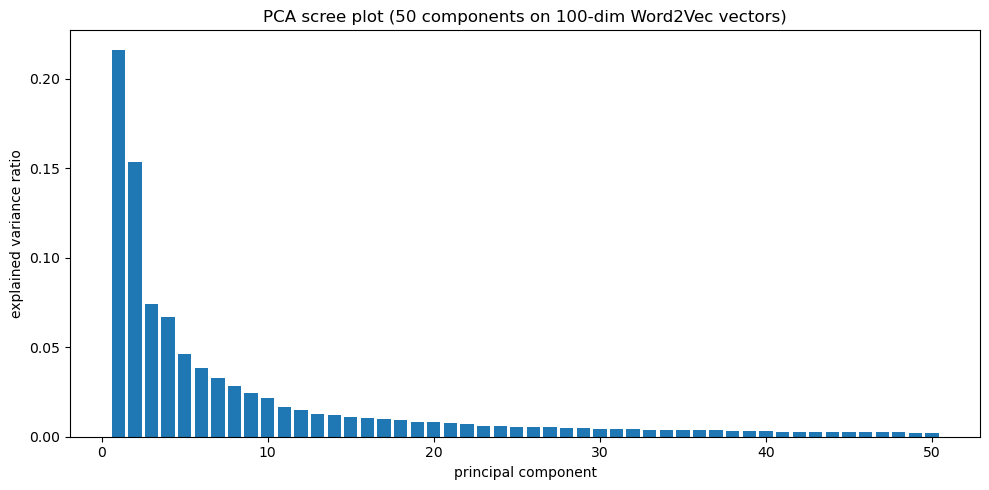

In [42]:
# 10c. Per-component explained variance (scree). pca_model was fit with k=PCA_K
# on the VECTOR_SIZE-dim Word2Vec vectors; explainedVariance is already sorted.
ev = pca_model.explainedVariance.toArray()      # length PCA_K, descending
cum_ev = np.cumsum(ev)
components = np.arange(1, len(ev) + 1)

print(f"PCA kept {len(ev)} of {VECTOR_SIZE} Word2Vec dimensions")
print(f"  component 1 explains {ev[0]:.4f} of total variance")
print(f"  top 10 components explain {cum_ev[9]:.4f}")
print(f"  all {len(ev)} kept components explain {cum_ev[-1]:.4f}")

# Plot 7: scree (explained-variance ratio per principal component).
plt.figure(figsize=(10, 5))
plt.bar(components, ev)
plt.xlabel('principal component')
plt.ylabel('explained variance ratio')
plt.title(f'PCA scree plot ({len(ev)} components on {VECTOR_SIZE}-dim Word2Vec vectors)')
plt.tight_layout()
plt.show()

### 10d. Cumulative variance and choice of k

Accumulating the §10c proportions gives the share of total variance retained as components are added (Plot 8). `comps_for` returns the fewest components whose cumulative variance reaches a target, falling back to all 50 if a target sits beyond what the kept components capture. `PCA_K_KEEP` takes the 90% point, a variance-justified trim that the §10e Logistic Regression and §10f K-Means run on, well below the full 100-dim Word2Vec width. §12 returns to this choice when it weighs the reduced features against the full set.

>=90% variance at 37 components (cumulative 0.9026)
>=95% variance at 50 components (cumulative 0.9381)
PCA_K_KEEP = 37  (downstream keeps the first 37 of 50 components)


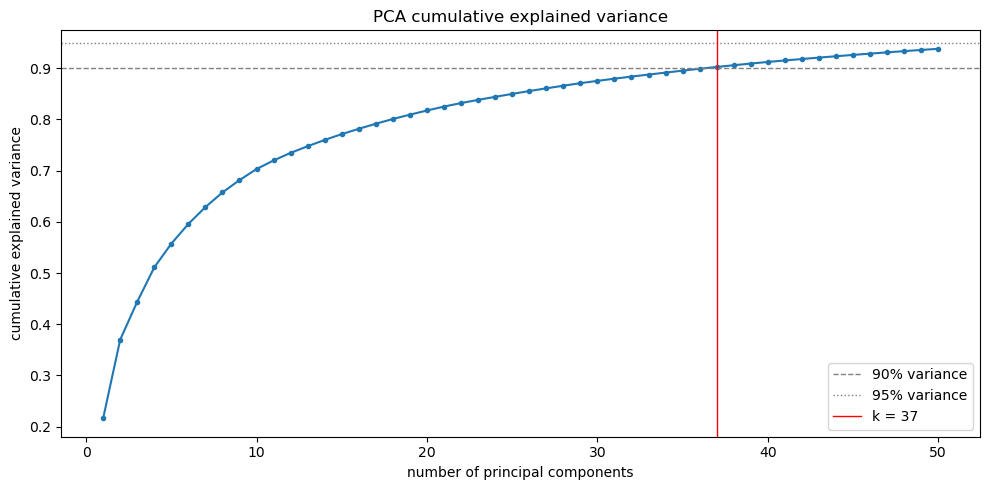

In [43]:
# 10d. Cumulative explained variance and the resulting k.
def comps_for(threshold):
    # Fewest components whose cumulative variance reaches `threshold`; falls back
    # to all kept components if the threshold sits beyond what they capture.
    hit = np.argmax(cum_ev >= threshold)
    return int(hit + 1) if cum_ev[hit] >= threshold else len(cum_ev)

k90 = comps_for(0.90)
k95 = comps_for(0.95)
PCA_K_KEEP = k90   # 90% point; the 95% target is beyond the 50 kept components. §10e/§10f run on these

print(f">=90% variance at {k90} components (cumulative {cum_ev[k90 - 1]:.4f})")
print(f">=95% variance at {k95} components (cumulative {cum_ev[k95 - 1]:.4f})")
print(f"PCA_K_KEEP = {PCA_K_KEEP}  (downstream keeps the first {PCA_K_KEEP} of {len(ev)} components)")

# Plot 8: cumulative explained variance with the 90% / 95% reference lines.
plt.figure(figsize=(10, 5))
plt.plot(components, cum_ev, marker='o', markersize=3)
plt.axhline(0.90, color='gray', linestyle='--', linewidth=1, label='90% variance')
plt.axhline(0.95, color='gray', linestyle=':', linewidth=1, label='95% variance')
plt.axvline(PCA_K_KEEP, color='red', linestyle='-', linewidth=1, label=f'k = {PCA_K_KEEP}')
plt.xlabel('number of principal components')
plt.ylabel('cumulative explained variance')
plt.title('PCA cumulative explained variance')
plt.legend()
plt.tight_layout()
plt.show()

### 10e. Logistic Regression on the reduced features

The supervised head of Model 2 is a multinomial `LogisticRegression` on the PCA-reduced features, which makes it directly comparable to the §7 RandomForest: the same §6g split, the same `label` indexing, and the same `MulticlassClassificationEvaluator` protocol over train, validation, and test. A `VectorSlicer` keeps the first `PCA_K_KEEP` components chosen in §10d, so the classifier sees the trimmed representation rather than all 50. No class weighting is applied, which matches Model 1; the residual `'other'` imbalance flagged in §6e is left for the §12 discussion. Parameters: `maxIter=20`, `regParam=0.0`.

In [44]:
# 10e. Multinomial Logistic Regression on the first PCA_K_KEEP PCA components.
# VectorSlicer trims pcaFeatures (50-dim) to the §10d choice; train2/val2/test2 are
# already cached, so the slice is a narrow, cheap transform rather than a re-scan.
slicer = VectorSlicer(inputCol='pcaFeatures', outputCol='pcaK', indices=list(range(PCA_K_KEEP)))
train2k = slicer.transform(train2)
val2k   = slicer.transform(val2)
test2k  = slicer.transform(test2)

lr2 = LogisticRegression(featuresCol='pcaK', labelCol='label', maxIter=20, regParam=0.0)
t0 = time.time()
lr2_model = lr2.fit(train2k)
lr2_fit_secs = time.time() - t0
print(f"LogisticRegression.fit wall-clock: {lr2_fit_secs:.1f} s  ({lr2_fit_secs / 60:.1f} min)")
print(f"  numClasses:  {lr2_model.numClasses}")
print(f"  numFeatures: {lr2_model.numFeatures}  (PCA_K_KEEP={PCA_K_KEEP})")

# Score all three folds on the §7b metrics; cache the test predictions for §11.
train_preds2 = lr2_model.transform(train2k)
val_preds2   = lr2_model.transform(val2k)
test_preds2  = lr2_model.transform(test2k).cache()

results2 = {}
for metric in ['accuracy', 'f1', 'weightedPrecision', 'weightedRecall']:
    evaluator = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName=metric)
    results2[metric] = (evaluator.evaluate(train_preds2), evaluator.evaluate(val_preds2), evaluator.evaluate(test_preds2))

print(f"\n{'metric':<20} {'train':>10} {'val':>10} {'test':>10} {'gap(tr-te)':>12}")
print("-" * 66)
for metric, (tr, va, te) in results2.items():
    print(f"{metric:<20} {tr:>10.4f} {va:>10.4f} {te:>10.4f} {tr - te:>+12.4f}")

LogisticRegression.fit wall-clock: 435.9 s  (7.3 min)
  numClasses:  52
  numFeatures: 37  (PCA_K_KEEP=37)

metric                    train        val       test   gap(tr-te)
------------------------------------------------------------------
accuracy                 0.8405     0.8402     0.8408      -0.0003
f1                       0.8045     0.8043     0.8052      -0.0007
weightedPrecision        0.7826     0.7824     0.7830      -0.0003
weightedRecall           0.8405     0.8402     0.8408      -0.0003


### 10f. K-Means on the reduced features: elbow and silhouette

The unsupervised view fits `KMeans` on the same `pcaK` features for k from 2 to 6 and reads two diagnostics per k: `trainingCost` (within-cluster sum of squares, the elbow curve) and the `ClusteringEvaluator` silhouette. To keep the five fits affordable the tuning runs on a cached 10% sample of the training fold, and the chosen k is the silhouette maximum. Plot 9 overlays both curves.

K-Means tuning sample: 274,696 rows
  k= 2: cost=     12458.8  silhouette=0.2479
  k= 3: cost=     11203.5  silhouette=0.2266
  k= 4: cost=     10603.2  silhouette=0.1973
  k= 5: cost=     10209.3  silhouette=0.1703
  k= 6: cost=      9879.7  silhouette=0.1478
chosen k (max silhouette) = 2  (silhouette 0.2479)


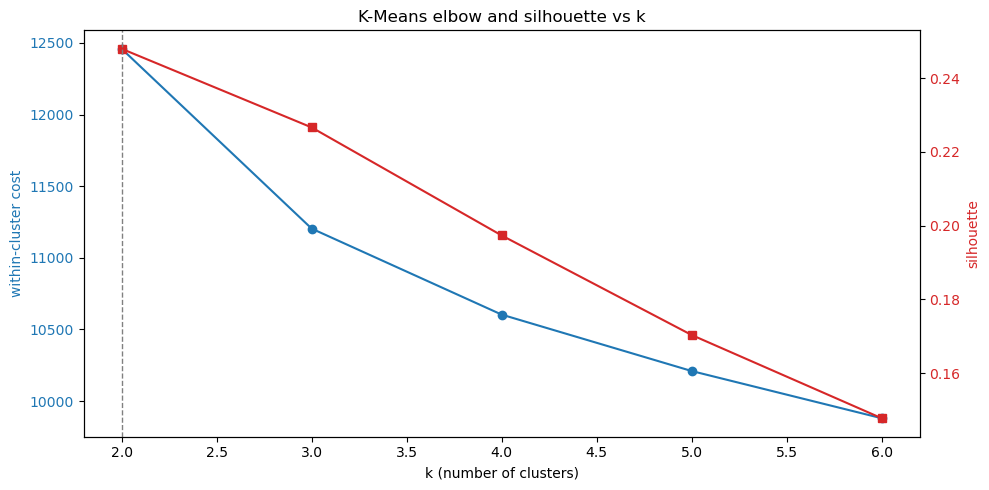

In [45]:
# 10f. K-Means sweep on a cached 10% training sample (keeps the five fits affordable).
km_sample = train2k.select('pcaK').sample(fraction=0.1, seed=42).cache()
print(f"K-Means tuning sample: {km_sample.count():,} rows")

sil_eval = ClusteringEvaluator(featuresCol='pcaK', predictionCol='prediction', metricName='silhouette')
ks = list(range(2, 7))
costs, sils = [], []
for k in ks:
    m = KMeans(featuresCol='pcaK', predictionCol='prediction', k=k, seed=42, maxIter=20).fit(km_sample)
    sil = sil_eval.evaluate(m.transform(km_sample))
    costs.append(m.summary.trainingCost)
    sils.append(sil)
    print(f"  k={k:>2}: cost={m.summary.trainingCost:>12.1f}  silhouette={sil:.4f}")

best_k = ks[int(np.argmax(sils))]
print(f"chosen k (max silhouette) = {best_k}  (silhouette {max(sils):.4f})")

# Plot 9: elbow (within-cluster cost) and silhouette vs k on a shared x-axis.
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(ks, costs, marker='o', color='tab:blue', label='within-cluster cost')
ax1.set_xlabel('k (number of clusters)')
ax1.set_ylabel('within-cluster cost', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.plot(ks, sils, marker='s', color='tab:red', label='silhouette')
ax2.set_ylabel('silhouette', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.axvline(best_k, color='gray', linestyle='--', linewidth=1)
plt.title('K-Means elbow and silhouette vs k')
fig.tight_layout()
plt.show()

### 10g. Cluster structure in the top two principal components

Refitting `KMeans` at the chosen k and projecting onto the first two principal components gives a 2-D view of the clusters. The scatter is a 5,000-row sample of the training fold coloured by cluster assignment; pc1 and pc2 are read straight from `pcaFeatures` with `vector_to_array`. Plot 10 shows whether the clusters separate along the directions that carry the most variance.

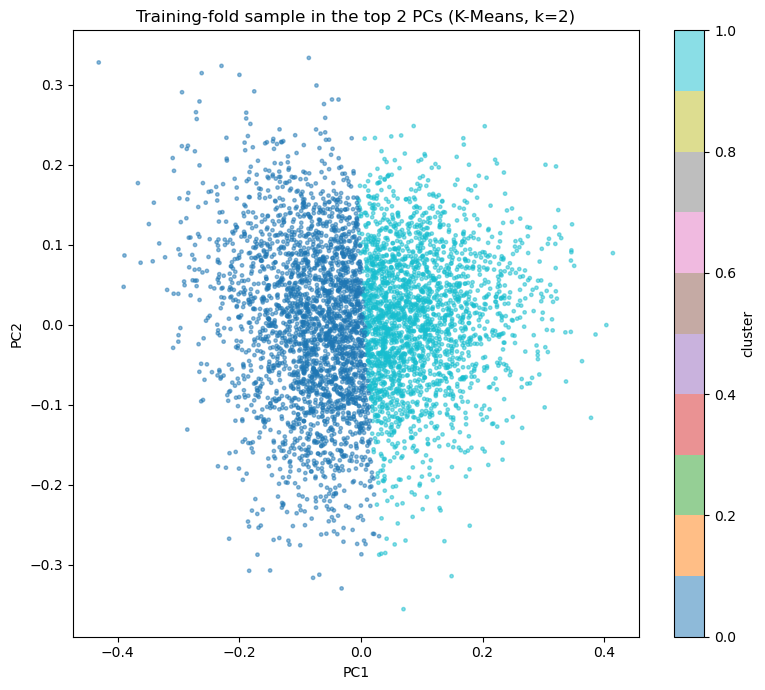

In [46]:
# 10g. Refit at best_k and scatter the first two PCs, coloured by cluster.
km_final = KMeans(featuresCol='pcaK', predictionCol='cluster', k=best_k, seed=42, maxIter=20).fit(km_sample)

scatter_pdf = (
    km_final.transform(train2k.sample(fraction=0.01, seed=42).limit(5000))
    .select(
        vector_to_array('pcaFeatures')[0].alias('pc1'),
        vector_to_array('pcaFeatures')[1].alias('pc2'),
        'cluster',
    )
    .toPandas()
)
km_sample.unpersist()

# Plot 10: 2-PC scatter coloured by K-Means cluster.
plt.figure(figsize=(8, 7))
sc = plt.scatter(scatter_pdf['pc1'], scatter_pdf['pc2'], c=scatter_pdf['cluster'],
                 cmap='tab10', s=6, alpha=0.5)
plt.colorbar(sc, label='cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Training-fold sample in the top 2 PCs (K-Means, k={best_k})')
plt.tight_layout()
plt.show()

## Section 11: Predictions analysis

This section reads Model 2's Logistic Regression predictions on the held-out test fold. It recovers the `CATEGORY` strings from the indexed predictions with the §6f label map, reports the correct/incorrect split, and pulls concrete correct, false-positive, and false-negative examples for the largest named category. The cached test fold dropped `TEXT` (the §6g/§10b heap reason), so examples are shown as (true, predicted) `CATEGORY` pairs. Plot 11 is the confusion matrix over the most frequent categories.

Test rows: 588,125   correct: 494,521   accuracy: 0.8408
Focus category for FP/FN examples: 'Harry Potter, Romance'

Correct classifications (named fandoms) (n=5):
                    CATEGORY           predicted_CATEGORY
                Harry Potter                 Harry Potter
       Harry Potter, Romance        Harry Potter, Romance
         Harry Potter, Humor          Harry Potter, Humor
       Harry Potter, Romance        Harry Potter, Romance
Harry Potter, Humor, Romance Harry Potter, Humor, Romance

False positives for 'Harry Potter, Romance' (predicted 'Harry Potter, Romance', truly something else) (n=5):
                         CATEGORY    predicted_CATEGORY
     Harry Potter, Drama, Romance Harry Potter, Romance
    Harry Potter, Family, Romance Harry Potter, Romance
                            other Harry Potter, Romance
     Harry Potter, Angst, Romance Harry Potter, Romance
Harry Potter, Friendship, Romance Harry Potter, Romance

False negatives for 'Harry Potter, Romanc

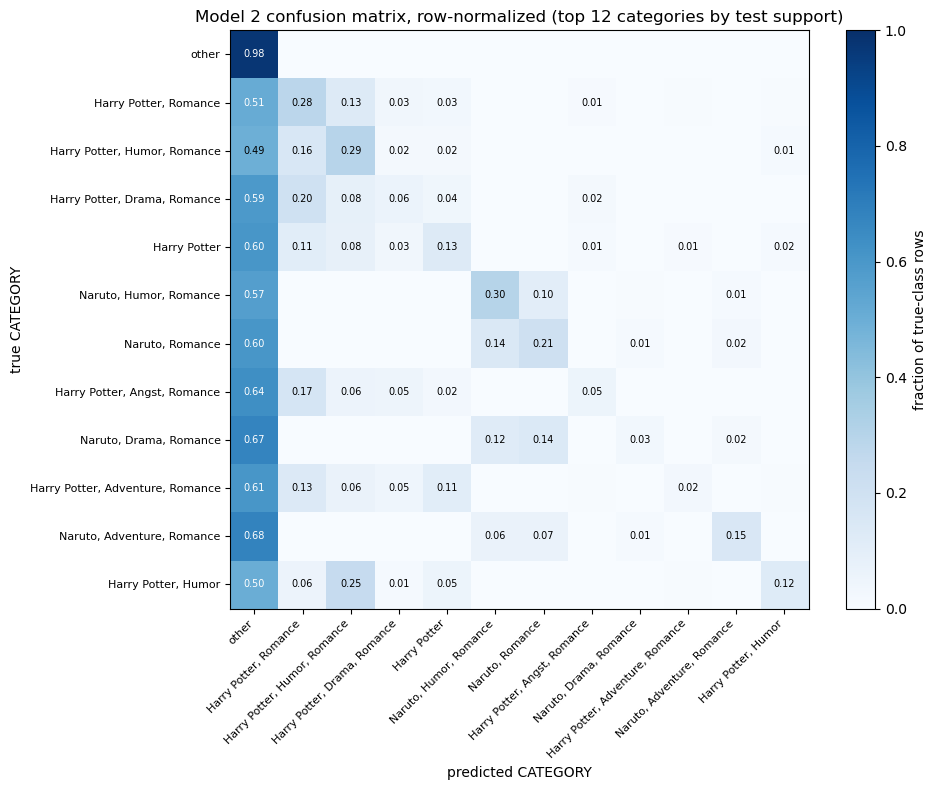

In [47]:
# 11. Decode predicted label indices back to CATEGORY and analyse the test predictions.
i2l = IndexToString(inputCol='prediction', outputCol='predicted_CATEGORY', labels=label_indexer_model.labels)
preds_lbl = (
    i2l.transform(test_preds2)
    .select('CATEGORY', 'predicted_CATEGORY')
    .withColumn('correct', F.col('CATEGORY') == F.col('predicted_CATEGORY'))
    .cache()
)
n_test = preds_lbl.count()
n_correct = preds_lbl.filter('correct').count()
print(f"Test rows: {n_test:,}   correct: {n_correct:,}   accuracy: {n_correct / n_test:.4f}")

# Focus class for FP/FN: the most frequent named category (excludes the 'other' rollup).
focus = (
    preds_lbl.filter(F.col('CATEGORY') != 'other')
    .groupBy('CATEGORY').count().orderBy(F.desc('count')).first()['CATEGORY']
)
print(f"Focus category for FP/FN examples: {focus!r}")


def show(df, title, n=5):
    pdf = df.select('CATEGORY', 'predicted_CATEGORY').limit(n).toPandas()
    print(f"\n{title} (n={n}):")
    print(pdf.to_string(index=False))


# Correct hits on NAMED fandoms; the 'other'->'other' hits dominate but say little.
show(preds_lbl.filter(F.col('correct') & (F.col('CATEGORY') != 'other')),
     "Correct classifications (named fandoms)")
show(preds_lbl.filter((F.col('predicted_CATEGORY') == focus) & (F.col('CATEGORY') != focus)),
     f"False positives for {focus!r} (predicted {focus!r}, truly something else)")
show(preds_lbl.filter((F.col('CATEGORY') == focus) & (F.col('predicted_CATEGORY') != focus)),
     f"False negatives for {focus!r} (truly {focus!r}, predicted otherwise)")

# Plot 11: row-normalized confusion matrix over the top-12 categories by test support.
# Each cell is the fraction of that TRUE class predicted as the column class, so the
# dominant 'other' class no longer saturates the scale and per-class behaviour is visible.
topK = [r['CATEGORY'] for r in
        preds_lbl.groupBy('CATEGORY').count().orderBy(F.desc('count')).limit(12).collect()]
support = {r['CATEGORY']: r['count'] for r in
          preds_lbl.filter(F.col('CATEGORY').isin(topK)).groupBy('CATEGORY').count().collect()}
counts = (
    preds_lbl
    .filter(F.col('CATEGORY').isin(topK) & F.col('predicted_CATEGORY').isin(topK))
    .groupBy('CATEGORY').pivot('predicted_CATEGORY', topK).count()
    .toPandas().set_index('CATEGORY').reindex(index=topK, columns=topK).fillna(0)
)
cm = counts.div(pd.Series(support).reindex(topK), axis=0)   # row-normalize by true-class support

plt.figure(figsize=(10, 8))
plt.imshow(cm.values, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(label='fraction of true-class rows')
plt.xticks(range(len(topK)), topK, rotation=45, ha='right', fontsize=8)
plt.yticks(range(len(topK)), topK, fontsize=8)
for i in range(len(topK)):
    for j in range(len(topK)):
        v = cm.values[i, j]
        if v >= 0.01:
            plt.text(j, i, f'{v:.2f}', ha='center', va='center',
                     color='white' if v > 0.5 else 'black', fontsize=7)
plt.xlabel('predicted CATEGORY')
plt.ylabel('true CATEGORY')
plt.title('Model 2 confusion matrix, row-normalized (top 12 categories by test support)')
plt.tight_layout()
plt.show()

preds_lbl.unpersist();

## Section 12: Model 2 fitting analysis

This section places Model 2 on the fitting graph, answers the Milestone 4 question of how dimensionality reduction affects results relative to the full feature set, and names the next models. It mirrors the §8 analysis for Model 1, reading the §10e train/validation/test table and the comparison cell below.

### 12a. Where on the fitting graph

Model 2's `LogisticRegression` on the 37 PCA components lands at train 0.8405, validation 0.8402, and test 0.8408 accuracy (§10e), a train-minus-test gap of about 0 on every metric. As in §8a, equal folds rule out overfitting: Model 2 sits on the left, high-bias side of the fitting graph, not the right.

It is, however, a better fit than the Model 1 RandomForest, and the metrics show how:

- F1 and precision rise while accuracy holds. Test accuracy (0.8408) is a hair below Model 1's (0.8428), which is the all-`'other'` majority-class accuracy, so Model 2 gives up a few majority-class freebies. But test F1 climbs to 0.8052 (Model 1: 0.7708) and weighted precision to 0.7830 (Model 1: 0.7102). Higher F1 at equal accuracy means the model now earns correct predictions on the minority named fandoms instead of labelling everything `'other'`.
- §11 shows where that gain stops. Model 1 predicted `'other'` for every §7c sample; Model 2 does predict real fandoms, but the confusion matrix (Plot 11) shows it has not escaped the majority class. `'other'` recall stays at 0.98, while roughly 0.5 to 0.7 of each named class still leaks into `'other'`, and the diagonal reaches only about 0.30 even for the best-recovered fandoms (Harry Potter and Naruto variants). The secondary error mode is confusion among neighbouring fandom-genre labels (for example `Harry Potter, Romance` versus `Harry Potter, Drama, Romance`). So Model 2 reduces the majority-class gravity rather than escaping it.

This confirms the §8c/§9 diagnosis: the bottleneck was feature information, not model capacity. Swapping the four numeric §6f features for dense Word2Vec prose embeddings lifted F1 by about 3.4 points and broke the all-`'other'` degeneracy, while the unaddressed class imbalance keeps headline accuracy pinned near the majority floor (see §12c).

### 12b. Dimensionality reduction versus the full feature set

The deployed Model 2 runs LR on the first 37 PCA components (the §10d 90%-variance point), trimmed from the 50-component PCA output, which in turn reduces the full 100-dim Word2Vec vectors. To measure what that reduction costs, the cell below refits the same LR (`maxIter=20`, `regParam=0.0`, same split and label indexer) at all three widths and reports train/validation/test metrics and fit time side by side.


In [48]:
# 12b. Dimensionality reduction vs. the full feature set.
# Refit the SAME multinomial LR (maxIter=20, regParam=0.0, same §6g split and §6f
# label indexer as §10e) at three feature widths drawn from one Word2Vec space:
#   - PCA 37  : the deployed Model 2 (90% variance, §10d)  -> reuse §10e `results2`
#   - PCA 50  : the full PCA output (93.8% variance)        -> cached `pcaFeatures`
#   - W2V 100 : the full Word2Vec vectors, pre-PCA          -> rebuilt from `w2v_model`
# This isolates what the PCA reduction costs in metrics and fit time.
import time
import pandas as pd
from pyspark.ml import PipelineModel

def _fold_metrics(model, frame):
    # Cache the small (label, prediction) frame once, then read all metrics off it.
    preds = model.transform(frame).select('label', 'prediction').cache()
    preds.count()
    out = {}
    for metric in ['accuracy', 'f1', 'weightedPrecision', 'weightedRecall']:
        ev = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName=metric)
        out[metric] = round(ev.evaluate(preds), 4)
    preds.unpersist()
    return out

cmp_rows = []

# --- PCA 37: reuse §10e results (no refit) ---
cmp_rows.append({
    'features': 'PCA 37 (deployed)', 'dim': PCA_K_KEEP, 'fit_secs': round(lr2_fit_secs, 1),
    'train_acc': results2['accuracy'][0], 'val_acc': results2['accuracy'][1], 'test_acc': results2['accuracy'][2],
    'test_f1': results2['f1'][2], 'test_wprec': results2['weightedPrecision'][2],
})

# --- PCA 50: full PCA output, straight off the cached pcaFeatures (no re-scan) ---
lr50 = LogisticRegression(featuresCol='pcaFeatures', labelCol='label', maxIter=20, regParam=0.0)
t0 = time.time(); m50 = lr50.fit(train2); secs50 = time.time() - t0
m50_tr = _fold_metrics(m50, train2); m50_va = _fold_metrics(m50, val2); m50_te = _fold_metrics(m50, test2)
cmp_rows.append({
    'features': 'PCA 50 (all comps)', 'dim': PCA_K, 'fit_secs': round(secs50, 1),
    'train_acc': m50_tr['accuracy'], 'val_acc': m50_va['accuracy'], 'test_acc': m50_te['accuracy'],
    'test_f1': m50_te['f1'], 'test_wprec': m50_te['weightedPrecision'],
})

# Free the 50-dim caches before building the wider 100-dim frames (driver-heap headroom).
for _d in (train2, val2, test2):
    _d.unpersist()

# --- W2V 100: full Word2Vec vectors (pre-PCA), rebuilt with the fitted text stages, no PCA.
#     ~15-20 min: re-scans each fold's TEXT once. Comment out this block to skip it. ---
w2v_only_model = PipelineModel(stages=[trunc, tokenizer, stopwords, cap, w2v_model])
def _prep_w2v(d):
    return label_indexer_model.transform(w2v_only_model.transform(d)).select('label', 'w2v')

train_w2v = _prep_w2v(train_df).cache(); train_w2v.count()
lr100 = LogisticRegression(featuresCol='w2v', labelCol='label', maxIter=20, regParam=0.0)
t0 = time.time(); m100 = lr100.fit(train_w2v); secs100 = time.time() - t0
m100_tr = _fold_metrics(m100, train_w2v)
m100_va = _fold_metrics(m100, _prep_w2v(val_df))
m100_te = _fold_metrics(m100, _prep_w2v(test_df))
train_w2v.unpersist()
cmp_rows.append({
    'features': 'W2V 100 (full, pre-PCA)', 'dim': VECTOR_SIZE, 'fit_secs': round(secs100, 1),
    'train_acc': m100_tr['accuracy'], 'val_acc': m100_va['accuracy'], 'test_acc': m100_te['accuracy'],
    'test_f1': m100_te['f1'], 'test_wprec': m100_te['weightedPrecision'],
})

cmp_df = pd.DataFrame(cmp_rows)
print("Model 2 LR -- dimensionality reduction vs. full feature set (same split, maxIter=20, regParam=0.0):")
print(cmp_df.to_string(index=False))


Model 2 LR -- dimensionality reduction vs. full feature set (same split, maxIter=20, regParam=0.0):
               features  dim  fit_secs  train_acc  val_acc  test_acc  test_f1  test_wprec
      PCA 37 (deployed)   37     435.9    0.84054 0.840224  0.840843  0.80524    0.782968
     PCA 50 (all comps)   50    1061.7    0.84280 0.842600  0.843100  0.80820    0.786700
W2V 100 (full, pre-PCA)  100     578.5    0.84240 0.841900  0.842400  0.80630    0.784600


**Reading the comparison.** The three feature widths are statistically tied: test accuracy is 0.8408 (37), 0.8431 (50), and 0.8424 (100), and test F1 is 0.8052, 0.8082, and 0.8063, a spread of about 0.3 points and within run-to-run noise. Two conclusions follow.

1. The reduction is essentially free. The 37-component model (90% variance) matches the full 100-dim Word2Vec on both metrics while using 63% fewer features. The fandom signal the classifier uses lives in the leading principal directions; the discarded tail behaves like noise for this task, exactly the trade the §10d trim was designed to make.
2. PCA slightly helps. The 50-component projection edges out the full 100-dim Word2Vec (0.8431 versus 0.8424 accuracy, 0.8082 versus 0.8063 F1), consistent with PCA dropping low-variance noise directions the raw embedding still carries. So here PCA is not a lossy compromise but a denoising step that costs nothing and marginally improves the fit.

The deployed 37-component model gives up about 0.3 F1 points for the leanest representation, which is the right call given that the §12a ceiling is the class imbalance, not the feature count. The `fit_secs` column is noisy, reflecting local-mode memory pressure and L-BFGS convergence rather than a clean function of dimension, so the metrics, not the seconds, carry the conclusion.

### 12c. Next models and future improvements

1. Break the majority-class floor. Neither model touches the roughly 84% `'other'` imbalance, which is now the binding ceiling on accuracy. Inverse-frequency class weights (`weightCol`) or resampling is the single highest-leverage next change, the natural Model 3.
2. Richer embeddings. The Word2Vec fit used a bounded 50k-document sample, `maxIter=1`, and a 1,000-token cap per story (§10b runtime levers). More documents, more iterations, or a larger `vectorSize` would sharpen the embedding before PCA.
3. Supervised reduction. PCA is unsupervised; an LDA projection (or training the classifier head end-to-end) would keep the directions that separate labels, not the directions of greatest variance.
4. Cross-lingual extension. Lifting the §6c English-only filter and evaluating per-language transfer on the top-six languages is the abstract's multilingual axis, still unrun.


## Section 13: Conclusion

Per the Milestone 4 instructions, the conclusion is its own section covering both models' results and their interpretation.

**Model 1: RandomForest on numeric features.** On the §6f pipeline (`text_len`, `perplexity_score`, and the engineered `text_len_log10` and `len_per_perplexity`, median-imputed and min-max scaled) over the top-50-fandom plus `'other'` target, the baseline `RandomForestClassifier(numTrees=20, maxDepth=5)` reached test accuracy 0.8428 with F1 0.7708, train, validation, and test agreeing on all four metrics (§7b), and every sampled prediction equal to `'other'` (§7c). The §8b capacity sweep (deeper and wider forests) moved no metric and opened no train-test gap. Model 1 is a severe underfit driven by a feature-information bottleneck, not model capacity (§8a, §8c): length and predictability do not encode which fandom a story belongs to.

**Model 2: Word2Vec, PCA, then LogisticRegression.** Acting on that diagnosis, Model 2 builds dense 100-dim Word2Vec document vectors from the prose, reduces them to 37 principal components (90% variance, §10d), and fits a multinomial LogisticRegression on the same §6g split. Test accuracy (0.8408) is statistically the same as Model 1's, but F1 rises to 0.8052 and weighted precision to 0.7830: Model 2 begins to predict the named fandoms instead of labelling everything `'other'`. The confusion matrix (Plot 11) keeps this in perspective: `'other'` still absorbs 0.5 to 0.7 of each named class, so the gain is real but bounded by the class imbalance, not an escape from it. The PCA reduction is free, and at 50 components slightly better than the full embedding (§12b). The unsupervised K-Means view (§10f) found only weak cluster structure (silhouette peaks at k = 2, 0.248, then decays), so the embedding does not form clean fandom clusters on its own; the supervised LR is what extracts the signal.

**Verdict and how to improve Model 2.** The project's central result is that changing the feature representation (numeric to prose embedding) helped where changing model capacity (the Model 1 sweep) did not. Model 2's ceiling is now the class imbalance rather than the features: with `'other'` at roughly 84% of rows, accuracy is pinned near the majority floor however well the minority classes are modelled. The highest-value next step is explicit imbalance handling (`weightCol` or resampling), followed by richer embeddings and a supervised reduction (LDA) in place of PCA. Both models were trained and evaluated at full corpus scale on SDSC Expanse; §14 reports the runtimes and where Spark's parallelism did and did not help.


## Section 14: Speedup and scaling analysis

All work ran on a single SDSC Expanse JupyterLab session (16 cores, 128 GB) launched in Spark `local[*]` mode (§1). "Parallelism" here therefore means 16 local task threads on one node, not distributed YARN executors: the driver JVM is the executor, the caveat documented in §1. The table below collects the wall-clock fit times captured live across §7, §8, and §10.


In [49]:
# §14. Runtime table: wall-clock for each model fit, assembled from the timing
# variables captured live in §7, §8b, §10b, and §10e. Runs instantly (no refit).
import pandas as pd
timing_df = pd.DataFrame([
    {'stage': 'Model 1  RF baseline (T=20, D=5)',    'fit_secs': round(train_secs, 1),       'fit_data': '2.74M-row train fold'},
    {'stage': 'Model 1  RF deeper (T=20, D=15)',      'fit_secs': round(deep_secs, 1),         'fit_data': '2.74M-row train fold'},
    {'stage': 'Model 1  RF wider (T=100, D=5)',       'fit_secs': round(wide_secs, 1),         'fit_data': '2.74M-row train fold'},
    {'stage': 'Model 2  Word2Vec + PCA fit',          'fit_secs': round(w2v_pca_fit_secs, 1),  'fit_data': '50k-doc bounded sample'},
    {'stage': 'Model 2  LogisticRegression (37-dim)', 'fit_secs': round(lr2_fit_secs, 1),      'fit_data': '2.74M-row train fold'},
])
timing_df['fit_min'] = (timing_df['fit_secs'] / 60).round(2)
print(timing_df.to_string(index=False))


                               stage  fit_secs               fit_data  fit_min
    Model 1  RF baseline (T=20, D=5)     145.1   2.74M-row train fold     2.42
     Model 1  RF deeper (T=20, D=15)     794.5   2.74M-row train fold    13.24
      Model 1  RF wider (T=100, D=5)     181.5   2.74M-row train fold     3.02
         Model 2  Word2Vec + PCA fit     362.5 50k-doc bounded sample     6.04
Model 2  LogisticRegression (37-dim)     435.9   2.74M-row train fold     7.26


**Where Spark's parallelism paid off.**

- Distributed I/O. Reading the 186 GB, 2,018-shard corpus and the per-fold TEXT scans spread across all 16 task slots. This is the dominant cost, and the part that is simply infeasible in pandas on one core, which is the reason the project needs Spark at all (§1).
- Word2Vec SGD runs across `numPartitions=16` (§10b), so the embedding fit is spread over the 16 threads.
- LogisticRegression aggregates gradients over the 2.74M-row train fold with a distributed tree-aggregate, collecting only the small 52-by-k coefficient block to the driver.

**Where it did not.**

- PCA's covariance SVD runs on the driver. `pyspark.ml.feature.PCA` builds the covariance matrix and runs a dense local SVD (§10's "why Word2Vec, not TF-IDF"). It is cheap here only because the input is 100-dim; a 2^18-dim TF-IDF matrix would not fit, which is exactly why the pipeline reduces dimensionality before any driver-side step.
- Serial driver work bounds the speedup. By Amdahl's law the driver-side pieces (the PCA SVD, the final coefficient collect, Python-side plotting) cap the parallel fraction, so adding threads has diminishing returns.

**Optimizations realized in the pipeline.**

- Single bounded scan and cache for the Word2Vec fit. Sampling, capping, tokenizing, and caching the 50k-doc fit set once (§10b) replaced a naive `Pipeline.fit` that silently recomputed the TEXT scan two to three times, roughly a 2-to-3-times cut in fit-phase I/O.
- Char-capping TEXT before tokenizing (`TEXT_CHAR_CAP = 8000`, §10b) was the dominant runtime lever: it bounds the tokenizer and stop-word cost per row on a TEXT column of roughly 160 GB, whose largest single record reaches about 93 MB.
- Disabling the vectorized Parquet reader (§1) trades roughly 2-to-3-times slower reads for stability on those roughly 93 MB records, which otherwise overflow the reader's batch buffers, a deliberate throughput-for-stability exchange.

**Toward a controlled speedup curve.** A rigorous strong-scaling study would re-time one fixed operation at `local[1, 2, 4, 8, 16]`, compute speedup S(p) = T(1) / T(p), and back out the parallel fraction via Amdahl's law. We leave this as future work: changing the local-mode thread count requires launching separate Spark sessions rather than an in-notebook sweep, so it could not be folded into this single-session run.
